In [21]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
from scipy.stats import zscore

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import matplotlib.ticker as mtick

import textwrap
import matplotlib.patches as patches


import cupy as cp
from cuml.manifold import TSNE
from cuml.decomposition import PCA

from matplotlib.patches import Patch
import matplotlib.ticker as ticker

sc.settings.verbosity = 2

# Load data

In [2]:
%%time
# fpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
fpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 514 ms, sys: 2 s, total: 2.51 s
Wall time: 5.11 s


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# Load genesets

In [3]:
def load_pathway(fpath):
    result = []
    with open(fpath) as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

mpath = "../../resources/PanglaoDB_Augmented_2021.txt"
pang = load_pathway(mpath)

cell_types = [
    'Fibroblasts',
    'Myocytes',
    'Myoblasts',
    'Myofibroblasts',
    'Pluripotent Stem Cells'
]

subset = pang[cell_types]

print("Marker genes per cell type:")
for ct in cell_types:
    print(f"{ct}: {subset[ct].sum()}")

panglao_markers = subset[subset.any(axis=1)]

print(f"\nTotal unique genes across selected types: {panglao_markers.shape[0]}")
panglao_markers.head()

fib_genes = panglao_markers['Fibroblasts'] == True
fib_genes =  panglao_markers[fib_genes].index
fib_genes = [g for g in fib_genes if g in adata.var_names]
print(f"N fib genes in adata: {len(fib_genes)}")


myo_genes = (panglao_markers['Myocytes'] == True) | (panglao_markers['Myoblasts'] == True)
myo_genes =  panglao_markers[myo_genes].index
myo_genes = [g for g in myo_genes if g in adata.var_names]
print(f"N myocyte/myoblast genes in adata: {len(myo_genes)}")

Marker genes per cell type:
Fibroblasts: 232
Myocytes: 163
Myoblasts: 126
Myofibroblasts: 100
Pluripotent Stem Cells: 112

Total unique genes across selected types: 563
N fib genes in adata: 220
N myocyte/myoblast genes in adata: 210


In [13]:
unique_to_fib = list(set(fib_genes) - set(myo_genes))
print(len(unique_to_fib))

unique_to_myo = list(set(myo_genes) - set(fib_genes))
print(len(unique_to_myo))

176
166


In [6]:
hallmark = pd.read_json("../../resources/HALLMARK_MYOGENESIS.v2026.1.Hs.json")
myogenesis = hallmark.loc['geneSymbols', 'HALLMARK_MYOGENESIS']
print(f'Total HALLMARK_MYOGENESIS genes: {len(myogenesis)}')


# overlap with panglao

overlap = list(set(myogenesis) & set(myo_genes))
print(len(overlap))

Total HALLMARK_MYOGENESIS genes: 200
43


In [7]:
# extract top expressed Fib genes from control group
n_genes = 15

cdata = adata[adata.obs['pooled_condition'] == 'Control', :].copy()
print(cdata.shape)

fib_genes_subset = [g for g in fib_genes if g in cdata.var_names]

cdata.X = cdata.layers['log_norm']

mean_expr = cdata[:, fib_genes_subset].X.mean(axis=0).A1  
top_fib_genes = [fib_genes_subset[i] for i in mean_expr.argsort()[::-1][:n_genes]]

print(len(top_fib_genes))
top_fib_genes

(6902, 25126)
15


['VIM',
 'COL1A2',
 'COL1A1',
 'S100A4',
 'DCN',
 'TAGLN',
 'SPARC',
 'FN1',
 'COL6A2',
 'COL6A1',
 'IGFBP6',
 'MYL9',
 'GREM1',
 'COL3A1',
 'FSTL1']

In [50]:
# extract top expressed myogenic genes from mmMYOD1 group

# first remove fibroblast genes
myo_no_fib = list(set(myo_genes) - set(fib_genes))
print(len(myo_no_fib))



n_genes = 15

cdata = adata[adata.obs['pooled_condition'] == 'mmMYOD1', :].copy()
print(cdata.shape)

myo_genes_subset = [g for g in myo_no_fib if g in cdata.var_names]

cdata.X = cdata.layers['log_norm']

mean_expr = cdata[:, myo_genes_subset].X.mean(axis=0).A1  
top_myo_genes = [myo_genes_subset[i] for i in mean_expr.argsort()[::-1][:n_genes]]

print(len(top_myo_genes))
top_myo_genes

166
(2109, 25042)
15


['TPM2',
 'RND3',
 'CALD1',
 'TPM1',
 'TNFRSF12A',
 'TSPAN9',
 'CAV1',
 'MYOD1',
 'TRIO',
 'CCL2',
 'TBX3',
 'PRKG1',
 'IGFBP5',
 'TEAD1',
 'UACA']

# Gene expression

## Myogenic

In [8]:
# Plot gene expression 

# # fib genes
# genes_to_plot = top_fib_genes.copy()

# # myogenic genes
genes_to_plot = [
    'MYOD1', 'MYOG', 'MYF5', 'MYF6', 'MYH1', 'MYH2', 'MYH3', 'MYH7', 'MYH8', 'DES', 'TTN', 'DMD', 
    'TNN2', 'ACTN2', 'SIX1', 'MEF2A', 'MEF2C', 'PAX7', 'PAX3', 'NCAM1',
    'TNNT3', 'TNNT2', 'ENO3', 
]

genes_to_plot = [g for g in genes_to_plot if g in adata.var_names]
print(genes_to_plot)


adata.X = adata.layers['log_norm']

bdata = adata[:, genes_to_plot].copy()
print(bdata.shape)

# dense format
X = bdata.X if isinstance(bdata.X, np.ndarray) else bdata.X.toarray()

df = pd.DataFrame(
    X,
    index=bdata.obs_names,
    columns=bdata.var_names,
)

print(df.shape)
df.head()

['MYOD1', 'MYF6', 'MYH2', 'MYH3', 'DES', 'TTN', 'DMD', 'ACTN2', 'SIX1', 'MEF2A', 'MEF2C', 'PAX7', 'PAX3', 'NCAM1', 'TNNT2', 'ENO3']
(16296, 16)
(16296, 16)


gene_name,MYOD1,MYF6,MYH2,MYH3,DES,TTN,DMD,ACTN2,SIX1,MEF2A,MEF2C,PAX7,PAX3,NCAM1,TNNT2,ENO3
AAACCAAAGCAACTGC_hybrid,2.306209,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.426279,0.724207,0.426279,0.0,0.426279,0.0,0.0,0.0
AAACCAAAGTAGGGCA_hybrid,1.635624,0.0,0.0,0.0,0.709594,0.0,0.0,0.000000,0.000000,0.709594,0.000000,0.0,0.000000,0.0,0.0,0.0
AAACCAAAGTCTAGGC_hybrid,1.135698,0.0,0.0,0.0,0.533242,0.0,0.0,0.301751,0.533242,0.879169,0.533242,0.0,0.000000,0.0,0.0,0.0
AAACCATTCACGTAAT_hybrid,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
AAACCATTCAGGCAGA_hybrid,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.433809,0.433809,0.000000,0.0,0.433809,0.0,0.0,0.0


In [9]:
# cell to condition mapping
cdf = adata.obs[['pooled_condition', 'leiden_split']].copy()
cdf = cdf.reset_index(names='cell_id')
print(cdf.shape)
cdf.head()

(16296, 3)


,cell_id,pooled_condition,leiden_split
0,AAACCAAAGCAACTGC_hybrid,siPRRX1/mmMYOD1,H1
1,AAACCAAAGTAGGGCA_hybrid,mmMYOD1,M1
2,AAACCAAAGTCTAGGC_hybrid,siPRRX1/mmMYOD1,H1
3,AAACCATTCACGTAAT_hybrid,siPRRX1,P1
4,AAACCATTCAGGCAGA_hybrid,siPRRX1,P1


In [10]:
df = df.reset_index(names='cell_id')

df1 = pd.merge(df, cdf, how='left', on='cell_id')
print(df1.shape)
df1.head()

(16296, 19)


,cell_id,MYOD1,MYF6,MYH2,MYH3,DES,TTN,DMD,ACTN2,SIX1,MEF2A,MEF2C,PAX7,PAX3,NCAM1,TNNT2,ENO3,pooled_condition,leiden_split
0,AAACCAAAGCAACTGC_hybrid,2.306209,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.426279,0.724207,0.426279,0.0,0.426279,0.0,0.0,0.0,siPRRX1/mmMYOD1,H1
1,AAACCAAAGTAGGGCA_hybrid,1.635624,0.0,0.0,0.0,0.709594,0.0,0.0,0.000000,0.000000,0.709594,0.000000,0.0,0.000000,0.0,0.0,0.0,mmMYOD1,M1
2,AAACCAAAGTCTAGGC_hybrid,1.135698,0.0,0.0,0.0,0.533242,0.0,0.0,0.301751,0.533242,0.879169,0.533242,0.0,0.000000,0.0,0.0,0.0,siPRRX1/mmMYOD1,H1
3,AAACCATTCACGTAAT_hybrid,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,siPRRX1,P1
4,AAACCATTCAGGCAGA_hybrid,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.433809,0.433809,0.000000,0.0,0.433809,0.0,0.0,0.0,siPRRX1,P1


In [11]:
# % expressing

pct_expressing = []

# # quantile thresholds
# q = 0.5
# thresholds = df1.groupby('pooled_condition', observed=True)[genes_to_plot].quantile(q)

# for cond, cond_df in df1.groupby('pooled_condition', observed=True):
#     for gene in genes_to_plot:
#         t = thresholds.loc[cond, gene]
#         expr_cells = (cond_df[gene] > t).sum()
#         total_cells = len(cond_df)
#         pct = expr_cells / total_cells * 100
#         pct_expressing.append({'gene': gene, 'condition': cond, 'thresh': t, 'pct_expressing': pct})
        
# for fib genes

t = 0

for cond, cond_df in df1.groupby('pooled_condition', observed=True):
    for gene in genes_to_plot:
        expr_cells = (cond_df[gene] > t).sum()
        total_cells = len(cond_df)
        pct = expr_cells / total_cells * 100
        pct_expressing.append({'gene': gene, 'condition': cond, 'thresh': t, 'pct_expressing': pct})      

        
pct_df = pd.DataFrame(pct_expressing)
print(pct_df.shape)
pct_df.head(15)

(64, 4)


,gene,condition,thresh,pct_expressing
0,MYOD1,Control,0,0.000000
1,MYF6,Control,0,0.144886
2,MYH2,Control,0,0.000000
3,MYH3,Control,0,0.623008
4,DES,Control,0,0.463634
5,TTN,Control,0,1.318458
6,DMD,Control,0,5.404231
7,ACTN2,Control,0,0.014489
8,SIX1,Control,0,27.658650
9,MEF2A,Control,0,37.438424


In [9]:
pct_df[pct_df['gene'] == 'NCAM1']

,gene,condition,thresh,pct_expressing
13,NCAM1,Control,0,0.086931
27,NCAM1,mmMYOD1,0,6.917960
41,NCAM1,siPRRX1,0,7.928319
55,NCAM1,siPRRX1/mmMYOD1,0,6.105324


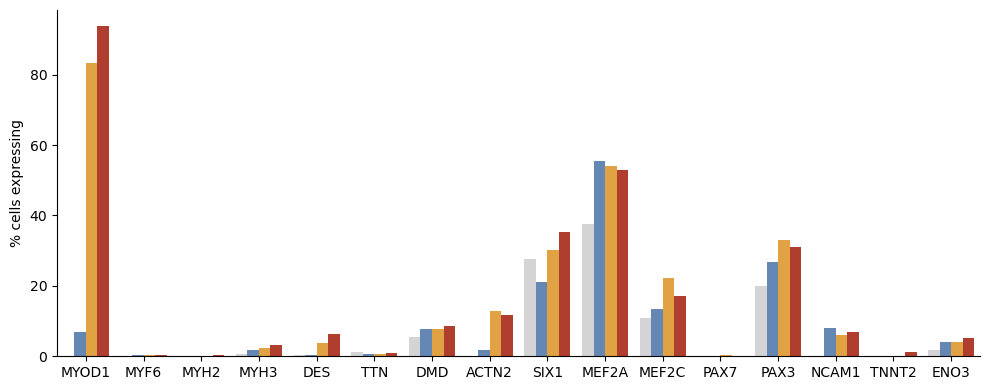

In [12]:
plt.figure(figsize=(10,4))

conditions = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
palette = ['#D3D4D8', '#5785C1', '#FBA72A', '#C52E19']

sns.barplot(
    data=pct_df, 
    x='gene', 
    y='pct_expressing', 
    hue='condition',
    palette=palette,
    hue_order=conditions,
    legend=False,
)

# plt.ylabel(f'% cells expressing above {int(q*100)}th percentile')
plt.ylabel(f'% cells expressing')
# plt.xticks(rotation=45)
plt.xlabel("")
# plt.legend(title='Condition')

sns.despine()
plt.tight_layout()
plt.show()

In [11]:
from scipy.stats import sem

expression_summary = []

for cond, cond_df in df1.groupby('pooled_condition', observed=True):
    for gene in genes_to_plot:
        expr_vals = cond_df[gene]
        mean_expr = expr_vals.mean()
        gene_sem = sem(expr_vals)
        expression_summary.append({
            'gene': gene,
            'condition': cond,
            'mean_expr': mean_expr,
            'sem': gene_sem
        })

expr_df = pd.DataFrame(expression_summary)

expr_df['mean_expr_scaled'] = expr_df.groupby('gene')['mean_expr'] \
    .transform(lambda x: (x - x.mean()) / x.std())

expr_df.head()

,gene,condition,mean_expr,sem,mean_expr_scaled
0,MYOD1,Control,0.000000,0.000000,-0.860073
1,MYF6,Control,0.000668,0.000217,-1.263648
2,MYH2,Control,0.000000,0.000000,-0.693598
3,MYH3,Control,0.003430,0.000533,-1.096719
4,DES,Control,0.002624,0.000476,-0.765109


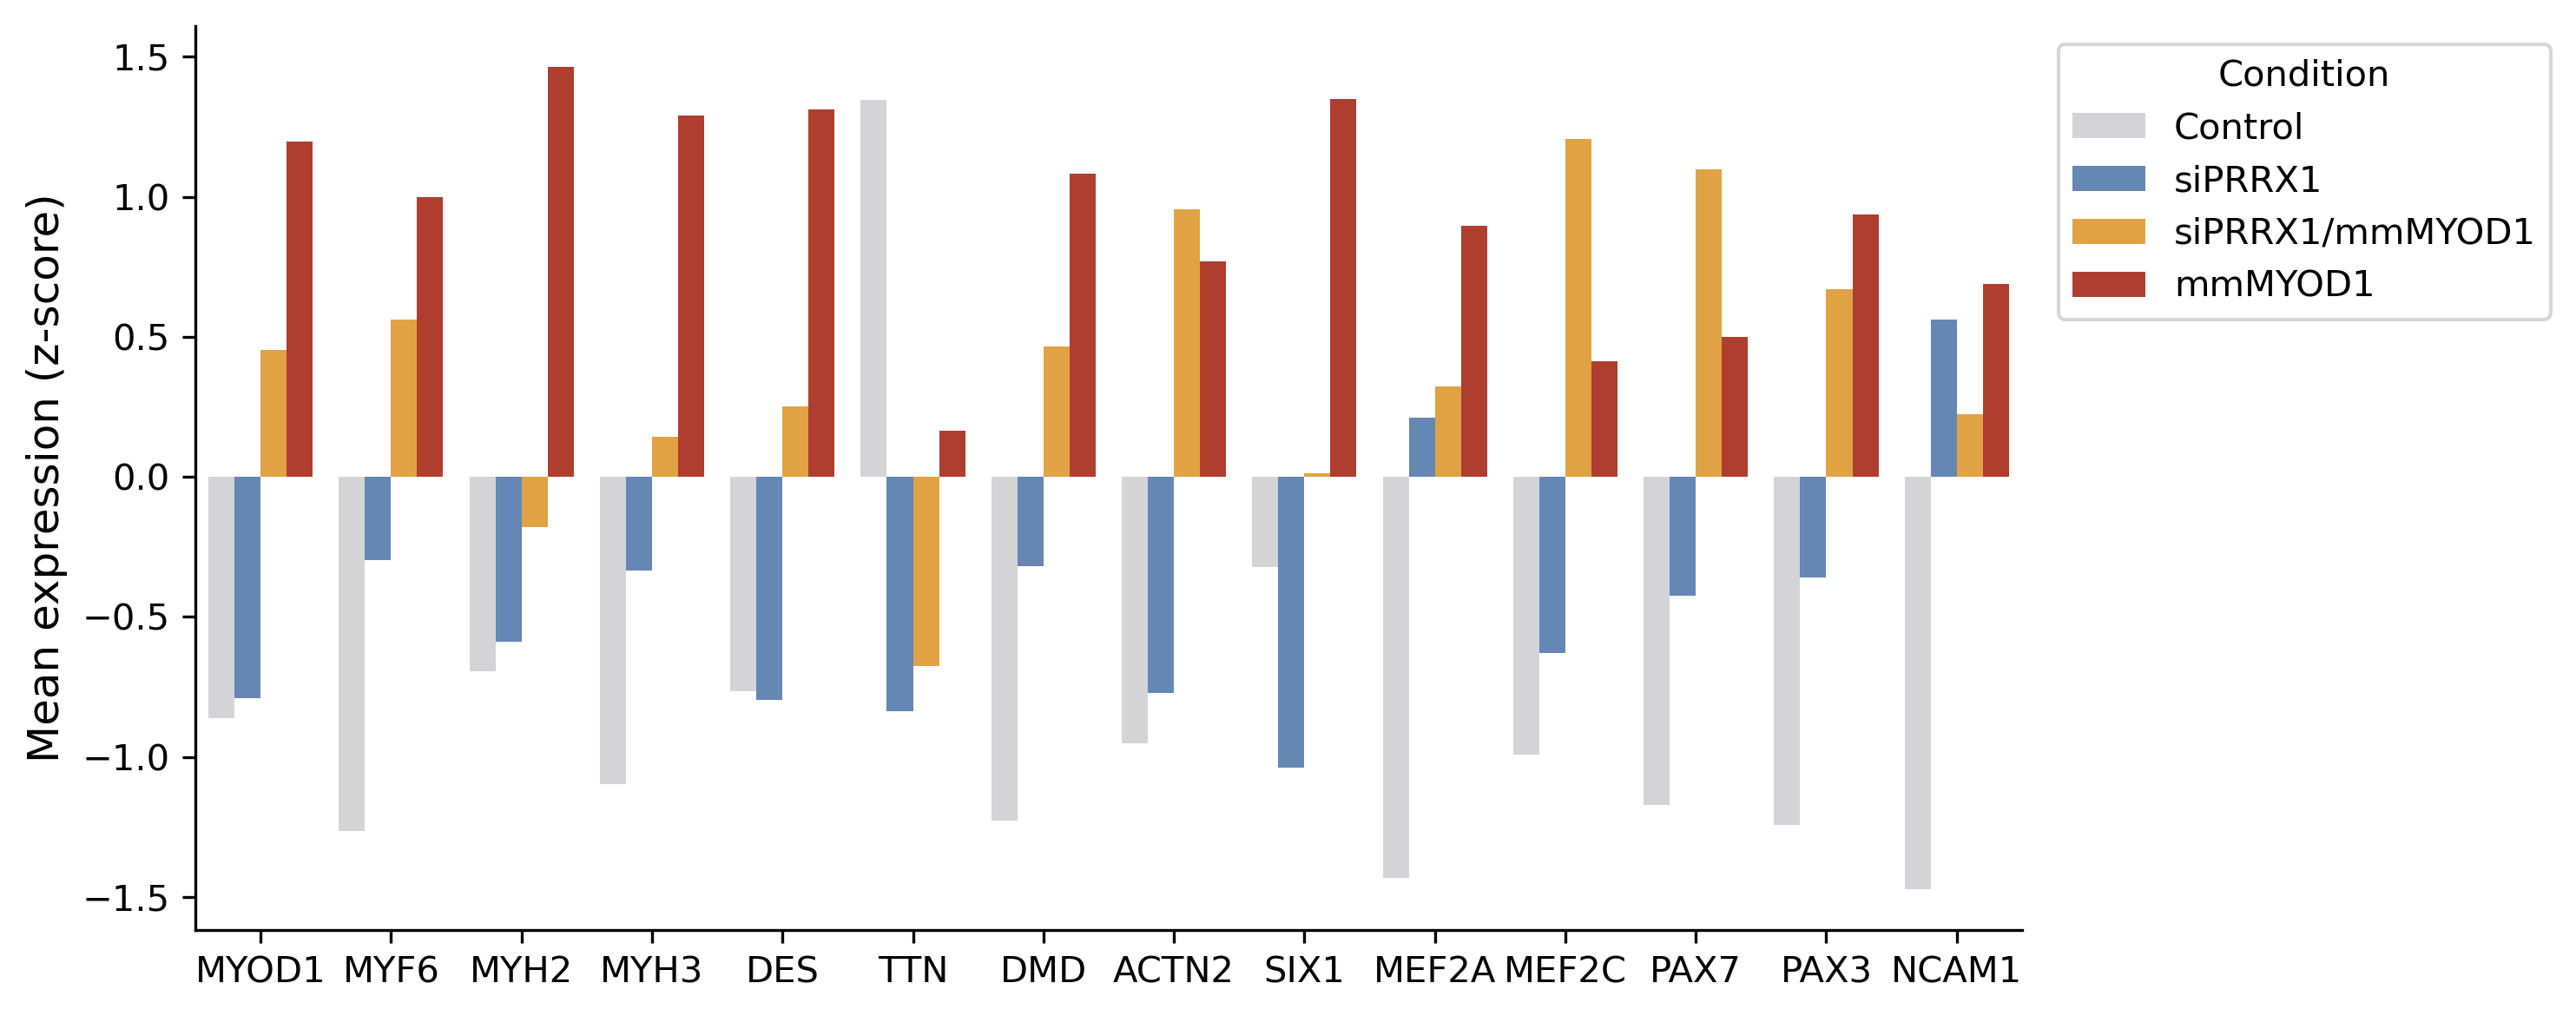

In [16]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

# Draw the barplot (no built-in CI, we'll add SEM manually)
bar_plot = sns.barplot(
    data=expr_df,
    x='gene',
    # y='mean_expr',
    y='mean_expr_scaled',
    hue='condition',
    palette=palette,
    hue_order=['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1'],
    ax=ax,
    capsize=0,       # No built-in errorbars
    errorbar=None    # Disable seaborn's automatic CI
)

# # --- Manually Add SEM Error Bars ---
# conditions = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
# genes = expr_df['gene'].unique()

# n_conditions = len(conditions)
# n_genes = len(genes)

# # Get the bar positions from the plot
# bar_containers = ax.containers  # One container per condition

# for cond_idx, (container, cond) in enumerate(zip(bar_containers, conditions)):
#     cond_data = expr_df[expr_df['condition'] == cond]

#     for bar, (_, row) in zip(container, cond_data.iterrows()):
#         x_pos = bar.get_x() + bar.get_width() / 2
#         y_pos = row['mean_expr']
#         sem_val = row['sem']

#         ax.errorbar(
#             x=x_pos,
#             y=y_pos,
#             yerr=sem_val,
#             fmt='none',         # No marker
#             color='black',
#             capsize=3,
#             linewidth=1.2
#         )

ax.set_xlabel('')
# ax.set_ylabel('Mean log-normalized expression', fontsize=12)
ax.set_ylabel('Mean expression (z-score)', fontsize=12)

ax.legend(title='Condition', bbox_to_anchor=(1.01, 1), loc='upper left')
# plt.xticks(rotation=45, ha='right')

# plt.ylim([0, 0.75])

sns.despine()
plt.tight_layout()
plt.show()

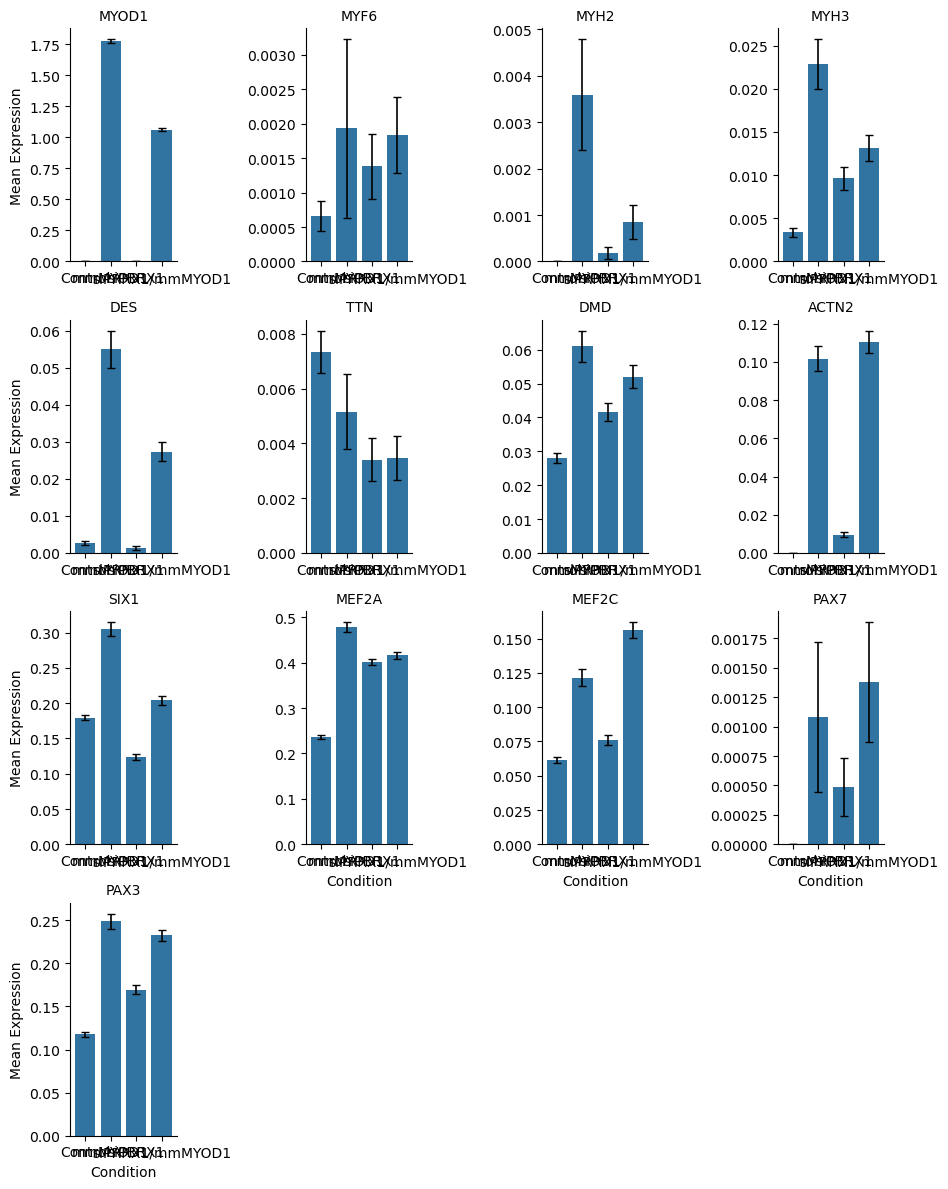

In [61]:
# def barplot_with_errorbars(data, **kwargs):
#     ax = plt.gca()
    
#     conditions = data['condition'].unique()
#     genes = data['gene'].unique()  # Should be 1 gene per facet
    
#     sns.barplot(
#         data=data,
#         x='condition',
#         y='mean_expr',
#         errorbar=None,
#         ax=ax
#     )
    
#     # Get all bar patches directly
#     bars = [p for p in ax.patches if p.get_width() > 0]
    
#     # Sort rows to match bar order
#     data_sorted = data.set_index('condition').loc[conditions].reset_index()
    
#     for bar, (_, row) in zip(bars, data_sorted.iterrows()):
#         ax.errorbar(
#             x=bar.get_x() + bar.get_width() / 2,
#             y=row['mean_expr'],
#             yerr=row['sem'],
#             fmt='none',
#             color='black',
#             capsize=3,
#             linewidth=1.2
#         )

# g = sns.FacetGrid(
#     expr_df,
#     col='gene',
#     col_wrap=4,
#     # hue='condition',
#     # palette='tab20',
#     sharey=False,
#     sharex=False,
#     height=3,
#     aspect=0.8
# )

# g.map_dataframe(barplot_with_errorbars)
# g.set_titles(col_template="{col_name}")
# g.set_axis_labels("Condition", "Mean Expression")
# plt.tight_layout()
# plt.show()

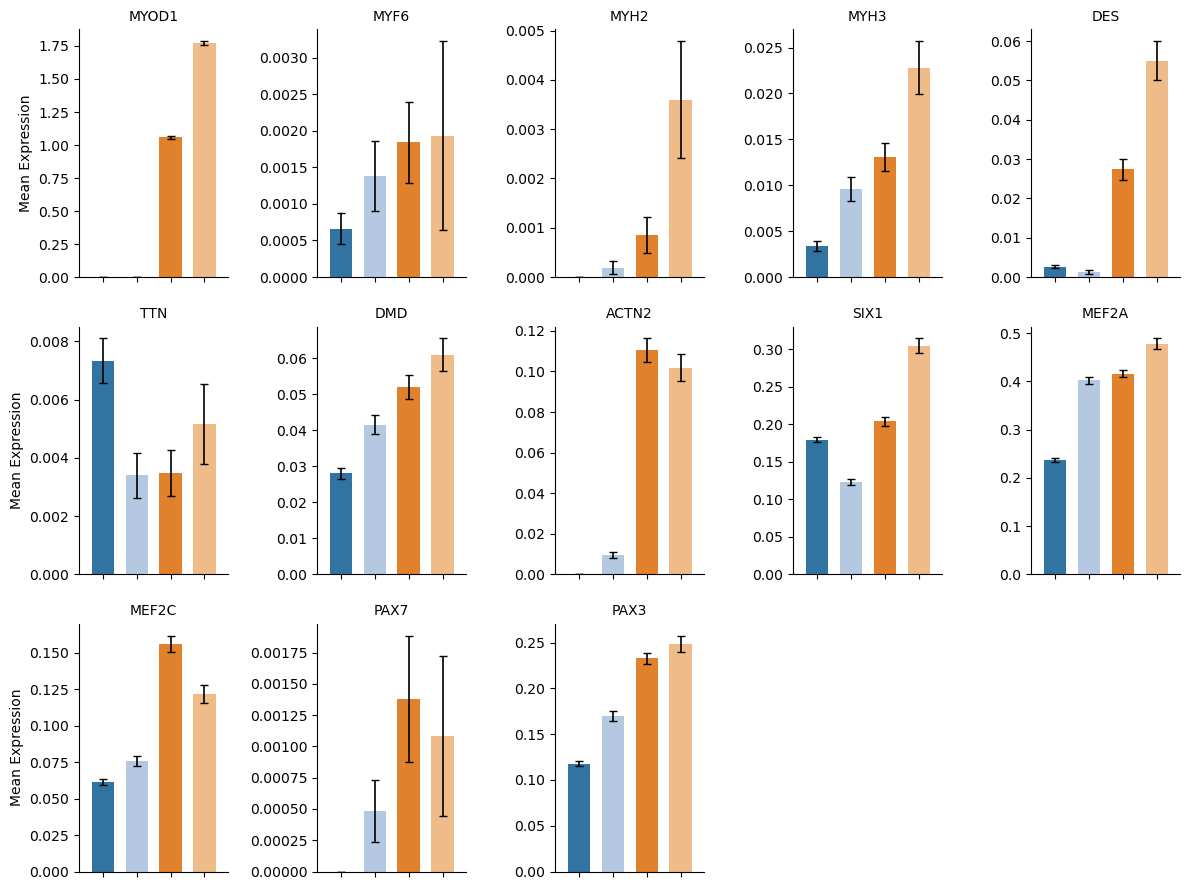

In [88]:
# # Define a color palette mapped to conditions
# conditions = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
# palette = sns.color_palette("tab20", n_colors=len(conditions))
# color_map = dict(zip(conditions, palette))

# def barplot_with_errorbars(data, **kwargs):
#     ax = plt.gca()
    
#     conditions_in_facet = data['condition'].unique()
#     bar_colors = [color_map[cond] for cond in conditions]
    
#     sns.barplot(
#         data=data,
#         x='condition',
#         y='mean_expr',
#         hue='condition',
#         order=conditions,
#         hue_order=conditions,
#         width=0.65,
#         legend=False,
#         errorbar=None,
#         palette=bar_colors,   # ← manually assign colors
#         ax=ax
#     )
    
#     bars = [p for p in ax.patches if p.get_width() > 0]
#     data_sorted = data.set_index('condition').loc[conditions].reset_index()
    
#     for bar, (_, row) in zip(bars, data_sorted.iterrows()):
#         ax.errorbar(
#             x=bar.get_x() + bar.get_width() / 2,
#             y=row['mean_expr'],
#             yerr=row['sem'],
#             fmt='none',
#             color='black',
#             capsize=3,
#             linewidth=1.2
#         )

        
# g = sns.FacetGrid(
#     expr_df,
#     col='gene',
#     col_wrap=5,
#     sharey=False,
#     sharex=False,
#     height=3,
#     aspect=0.8
# )

# g.map_dataframe(barplot_with_errorbars)
# g.set_titles(col_template="{col_name}")
# g.set_axis_labels("Condition", "Mean Expression")

# for ax in g.axes.flat:
#     ax.set_xticklabels([])
#     ax.set_xlabel('')
#     ax.margins(x=0.1)
    
# plt.tight_layout()
# g.fig.subplots_adjust(hspace=0.2, wspace=0.6)
# plt.show()

In [12]:
# legend_handles = [Patch(color=color_map[cond], label=cond) for cond in conditions]
# g.axes.flat[-1].legend(
#     handles=legend_handles,
#     title='Condition',
#     bbox_to_anchor=(1.5, 0.8),  # ← increase x to push further right
#     loc='lower right'
# )

def format_axis_scientific(ax):
    """
    If the y-axis max value has more than 3 digits (i.e., requires small decimals),
    rescale the ticks and add a multiplier label at the top of the axis.
    """
    ymax = ax.get_ylim()[1]
    
    # Find the order of magnitude
    if ymax == 0:
        return
    
    magnitude = np.floor(np.log10(abs(ymax)))
    
    # Only rescale if magnitude is <= -3 (e.g., 0.001, 0.0001, etc.)
    if magnitude <= -3:
        scale = 10 ** magnitude
        
        # Rescale the tick labels
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{x / scale:.2f}')
        )
        
        # Add multiplier label at the top of the y-axis
        ax.text(
            0, 1.02,                          # Just above the y-axis
            f'1e{int(magnitude)}',
            transform=ax.transAxes,
            fontsize=9,
            va='bottom',
            ha='left'
        )

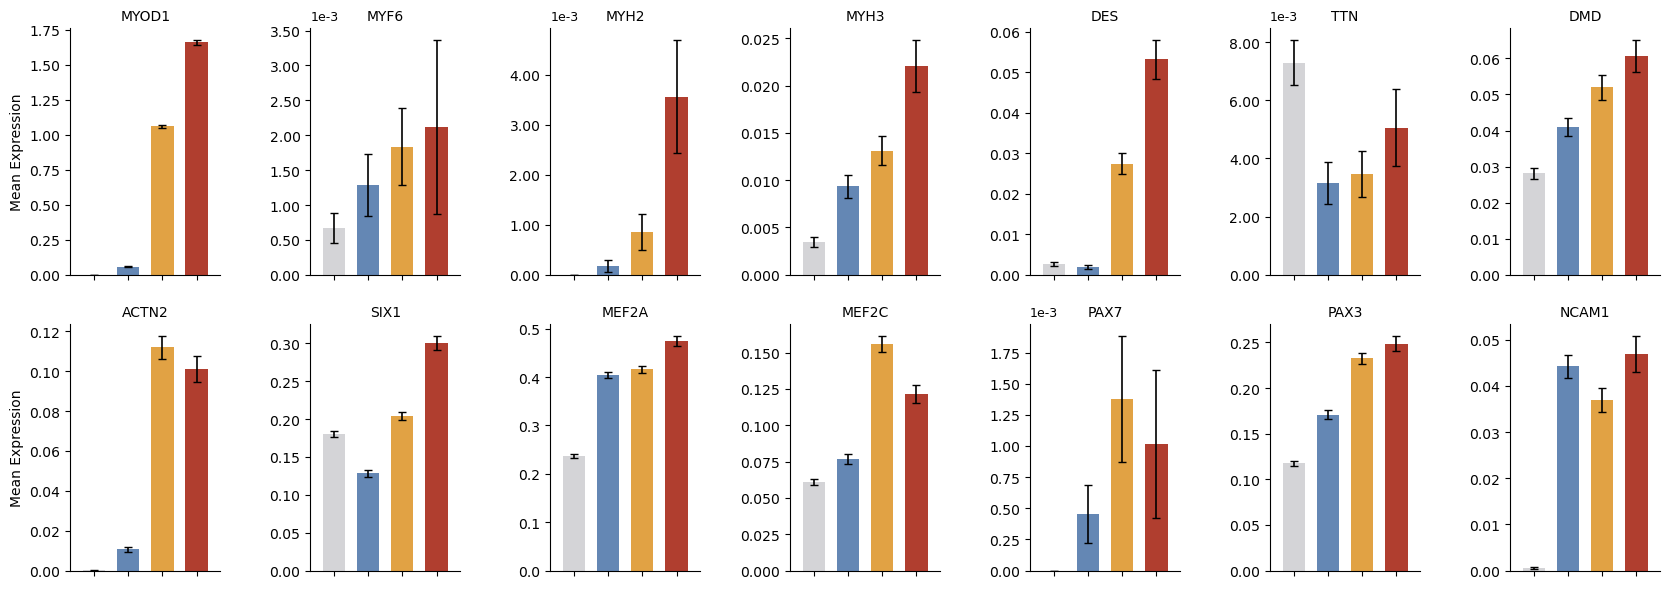

In [14]:
# Define a color palette mapped to conditions
conditions = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
palette = ['#D3D4D8', '#5785C1', '#FBA72A', '#C52E19']

# palette = sns.color_palette("tab20", n_colors=len(conditions))
color_map = dict(zip(conditions, palette))

def barplot_with_errorbars(data, **kwargs):
    ax = plt.gca()
    
    conditions_in_facet = data['condition'].unique()
    bar_colors = [color_map[cond] for cond in conditions]
    
    sns.barplot(
        data=data,
        x='condition',
        y='mean_expr',
        hue='condition',
        order=conditions,
        hue_order=conditions,
        width=0.65,
        legend=False,
        errorbar=None,
        palette=bar_colors,   # ← manually assign colors
        ax=ax
    )
    
    bars = [p for p in ax.patches if p.get_width() > 0]
    data_sorted = data.set_index('condition').loc[conditions].reset_index()
    
    for bar, (_, row) in zip(bars, data_sorted.iterrows()):
        ax.errorbar(
            x=bar.get_x() + bar.get_width() / 2,
            y=row['mean_expr'],
            yerr=row['sem'],
            fmt='none',
            color='black',
            capsize=3,
            linewidth=1.2
        )

        
g = sns.FacetGrid(
    expr_df,
    col='gene',
    col_wrap=7,
    # col_wrap=5,
    sharey=False,
    sharex=False,
    height=3,
    aspect=0.8
)

g.map_dataframe(barplot_with_errorbars)
g.set_titles(col_template="{col_name}", fontsize=20)
g.set_axis_labels("Condition", "Mean Expression")

for ax in g.axes.flat:
    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.margins(x=0.1)
    format_axis_scientific(ax)
    
plt.tight_layout()
g.fig.subplots_adjust(hspace=0.2, wspace=0.6)
plt.show()

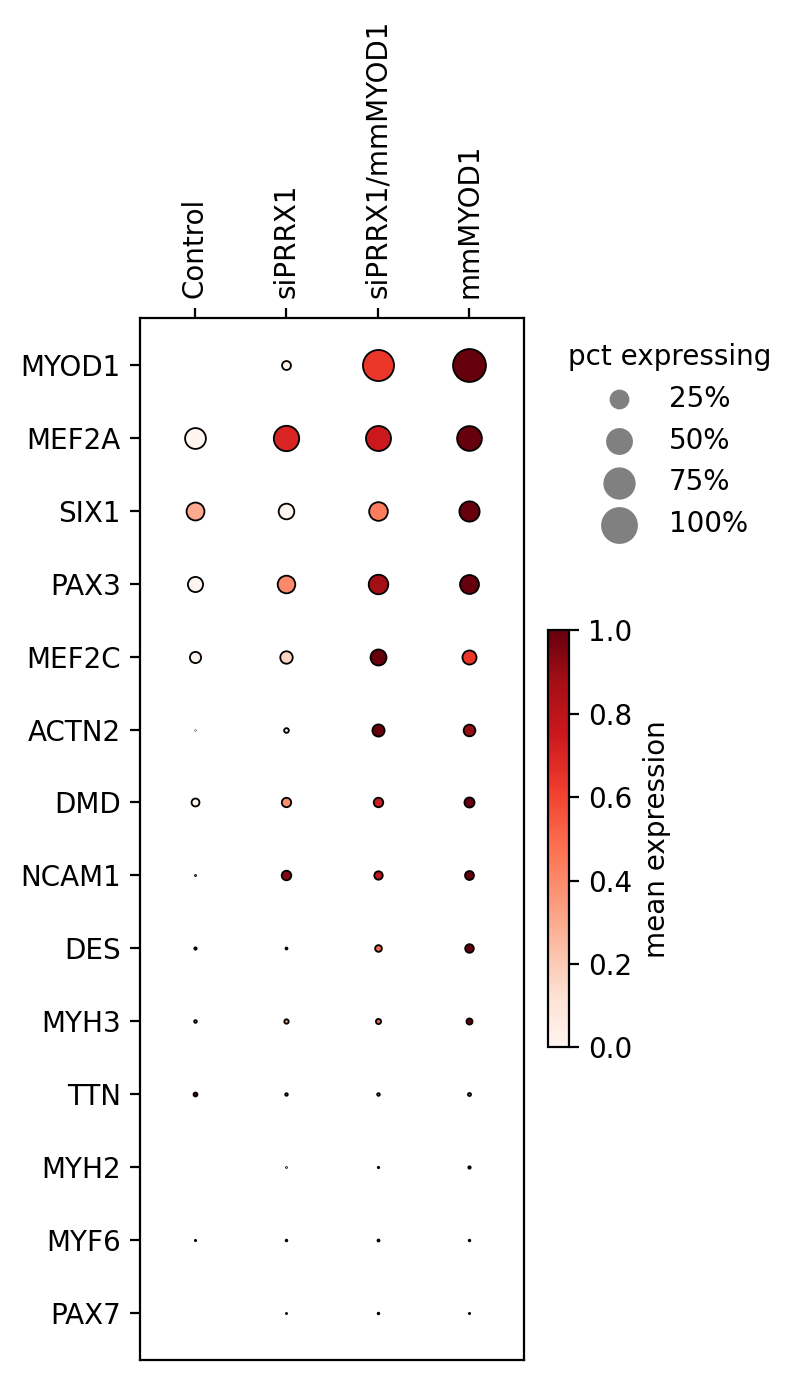

In [15]:
# # Myogenic
# genes_to_plot = [
#     'MYOD1', 'MYOG', 'MYF5', 'MYF6', 'MYH1', 'MYH2', 'MYH3', 'MYH7', 'MYH8', 'DES', 'TTN', 'DMD', 'TNN2', 'TNNT3', 'TNNI1', 
#     'ACTN2', 'SIX1', 'MEF2A', 'MEF2C', 'MEF2D', 'PAX7', 'PAX3', 'MSC', 
# ]


# genes_to_plot = [g for g in genes_to_plot if g in adata.var_names]



# groups = adata.obs['leiden_split'].unique()
# groups = adata.obs['pooled_condition'].unique()
groups = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
# groups = sorted(groups)

avg_expr = pd.DataFrame(index=genes_to_plot, columns=groups)
pct_expr = pd.DataFrame(index=genes_to_plot, columns=groups)

adata.X = adata.layers['log_norm'].copy()

for g in groups:
    # cells = adata.obs['leiden_split'] == g
    cells = adata.obs['pooled_condition'] == g
    data = adata[cells, genes_to_plot].X
    # If sparse matrix
    if not isinstance(data, np.ndarray):
        data = data.toarray()
    avg_expr[g] = data.mean(axis=0)
    pct_expr[g] = (data > 0).mean(axis=0) * 100

    
avg_expr_scaled = (avg_expr.T - avg_expr.min(axis=1)) / (avg_expr.max(axis=1) - avg_expr.min(axis=1))
avg_expr_scaled = avg_expr_scaled.T

# # sort for plotting
# myogenic
pct_expr = pct_expr.sort_values(by='mmMYOD1')
genes = list(pct_expr.index)

# # fibroblast
# avg_expr_scaled = avg_expr_scaled.sort_values(by='Control')
# genes = list(avg_expr_scaled.index)

# # Z-score by gene
# avg_expr = avg_expr.T   
# avg_expr_z = avg_expr.apply(scipy.stats.zscore, axis=0)
# avg_expr_z = avg_expr_z.T

# print(avg_expr_z.shape)
# avg_expr_z.head()  

cmap = 'Reds'
size_scale = 1.5

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 7
fig, ax = plt.subplots()

for i, gene in enumerate(genes):
    for j, cluster in enumerate(groups):
        size = float(pct_expr.loc[gene, cluster])*size_scale
        color = float(avg_expr_scaled.loc[gene, cluster])
        
        ax.scatter(
            x=j, 
            y=i, 
            s=size, 
            c=[color], 
            linewidths=0.65,
            edgecolors='k',
            cmap=cmap,
            vmin=0, 
            vmax=1, 
        )
        
ax.set_yticks(range(len(genes)))
ax.set_yticklabels(genes)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, rotation=90)
ax.xaxis.set_label_position('top') 
ax.xaxis.tick_top()
ax.set_xlabel('')

ax.margins(x=0.2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.05)
cbar.set_label('mean expression')


sizes = [25, 50, 75, 100]
markers = [plt.scatter([], [], s=s*size_scale, color='gray') for s in sizes]
labels = [f"{s}%" for s in sizes]

ax.legend(markers, labels, title="pct expressing", scatterpoints=1,
          frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

## Fibroblast

In [20]:
# Plot gene expression 

# fib genes
genes_to_plot = top_fib_genes.copy()


genes_to_plot = [g for g in genes_to_plot if g in adata.var_names]
print(genes_to_plot)


adata.X = adata.layers['log_norm']

bdata = adata[:, genes_to_plot].copy()
print(bdata.shape)

# dense format
X = bdata.X if isinstance(bdata.X, np.ndarray) else bdata.X.toarray()

df = pd.DataFrame(
    X,
    index=bdata.obs_names,
    columns=bdata.var_names,
)

print(df.shape)
df.head()

['VIM', 'COL1A2', 'COL1A1', 'S100A4', 'DCN', 'TAGLN', 'SPARC', 'FN1', 'COL6A2', 'COL6A1', 'IGFBP6', 'MYL9', 'GREM1', 'COL3A1', 'FSTL1']
(16296, 15)
(16296, 15)


gene_name,VIM,COL1A2,COL1A1,S100A4,DCN,TAGLN,SPARC,FN1,COL6A2,COL6A1,IGFBP6,MYL9,GREM1,COL3A1,FSTL1
AAACCAAAGCAACTGC_hybrid,4.020866,1.843003,0.953449,3.126473,0.426279,0.426279,1.551985,1.296845,0.426279,1.658681,1.755083,0.953449,0.724207,0.724207,1.139815
AAACCAAAGTAGGGCA_hybrid,3.026752,0.709594,2.108047,3.026752,0.709594,0.000000,1.635624,1.120481,0.000000,0.000000,1.635624,0.709594,1.410864,0.000000,0.000000
AAACCAAAGTCTAGGC_hybrid,3.853151,3.420570,2.845044,2.824356,1.339673,1.944168,2.563073,2.282954,0.721090,1.135698,1.718994,1.509008,2.282954,0.879169,1.135698
AAACCATTCACGTAAT_hybrid,3.982746,2.331530,2.107594,2.920725,0.709331,2.514380,1.635208,1.410473,1.410473,1.120133,1.973496,0.709331,0.000000,1.120133,2.331530
AAACCATTCAGGCAGA_hybrid,3.806508,2.785472,2.213411,3.298424,1.154519,2.152197,1.448974,1.676160,0.966745,0.433809,2.152197,1.569005,0.000000,0.735367,1.312546


In [21]:
# cell to condition mapping
cdf = adata.obs[['pooled_condition', 'leiden_split']].copy()
cdf = cdf.reset_index(names='cell_id')
print(cdf.shape)
cdf.head()

(16296, 3)


,cell_id,pooled_condition,leiden_split
0,AAACCAAAGCAACTGC_hybrid,siPRRX1/mmMYOD1,H1
1,AAACCAAAGTAGGGCA_hybrid,mmMYOD1,M1
2,AAACCAAAGTCTAGGC_hybrid,siPRRX1/mmMYOD1,H1
3,AAACCATTCACGTAAT_hybrid,siPRRX1,P1
4,AAACCATTCAGGCAGA_hybrid,siPRRX1,P1


In [22]:
df = df.reset_index(names='cell_id')

df1 = pd.merge(df, cdf, how='left', on='cell_id')
print(df1.shape)
df1.head()

(16296, 18)


,cell_id,VIM,COL1A2,COL1A1,S100A4,DCN,TAGLN,SPARC,FN1,COL6A2,COL6A1,IGFBP6,MYL9,GREM1,COL3A1,FSTL1,pooled_condition,leiden_split
0,AAACCAAAGCAACTGC_hybrid,4.020866,1.843003,0.953449,3.126473,0.426279,0.426279,1.551985,1.296845,0.426279,1.658681,1.755083,0.953449,0.724207,0.724207,1.139815,siPRRX1/mmMYOD1,H1
1,AAACCAAAGTAGGGCA_hybrid,3.026752,0.709594,2.108047,3.026752,0.709594,0.000000,1.635624,1.120481,0.000000,0.000000,1.635624,0.709594,1.410864,0.000000,0.000000,mmMYOD1,M1
2,AAACCAAAGTCTAGGC_hybrid,3.853151,3.420570,2.845044,2.824356,1.339673,1.944168,2.563073,2.282954,0.721090,1.135698,1.718994,1.509008,2.282954,0.879169,1.135698,siPRRX1/mmMYOD1,H1
3,AAACCATTCACGTAAT_hybrid,3.982746,2.331530,2.107594,2.920725,0.709331,2.514380,1.635208,1.410473,1.410473,1.120133,1.973496,0.709331,0.000000,1.120133,2.331530,siPRRX1,P1
4,AAACCATTCAGGCAGA_hybrid,3.806508,2.785472,2.213411,3.298424,1.154519,2.152197,1.448974,1.676160,0.966745,0.433809,2.152197,1.569005,0.000000,0.735367,1.312546,siPRRX1,P1


In [23]:
# % expressing

pct_expressing = []

# # quantile thresholds
# q = 0.5
# thresholds = df1.groupby('pooled_condition', observed=True)[genes_to_plot].quantile(q)

# for cond, cond_df in df1.groupby('pooled_condition', observed=True):
#     for gene in genes_to_plot:
#         t = thresholds.loc[cond, gene]
#         expr_cells = (cond_df[gene] > t).sum()
#         total_cells = len(cond_df)
#         pct = expr_cells / total_cells * 100
#         pct_expressing.append({'gene': gene, 'condition': cond, 'thresh': t, 'pct_expressing': pct})
        
# for fib genes

t = 0

for cond, cond_df in df1.groupby('pooled_condition', observed=True):
    for gene in genes_to_plot:
        expr_cells = (cond_df[gene] > t).sum()
        total_cells = len(cond_df)
        pct = expr_cells / total_cells * 100
        pct_expressing.append({'gene': gene, 'condition': cond, 'thresh': t, 'pct_expressing': pct})      

        
pct_df = pd.DataFrame(pct_expressing)
print(pct_df.shape)
pct_df.head(15)

(60, 4)


,gene,condition,thresh,pct_expressing
0,VIM,Control,0,100.000000
1,COL1A2,Control,0,100.000000
2,COL1A1,Control,0,100.000000
3,S100A4,Control,0,99.724717
4,DCN,Control,0,99.869603
5,TAGLN,Control,0,96.942915
6,SPARC,Control,0,99.840626
7,FN1,Control,0,99.376992
8,COL6A2,Control,0,99.797160
9,COL6A1,Control,0,99.478412


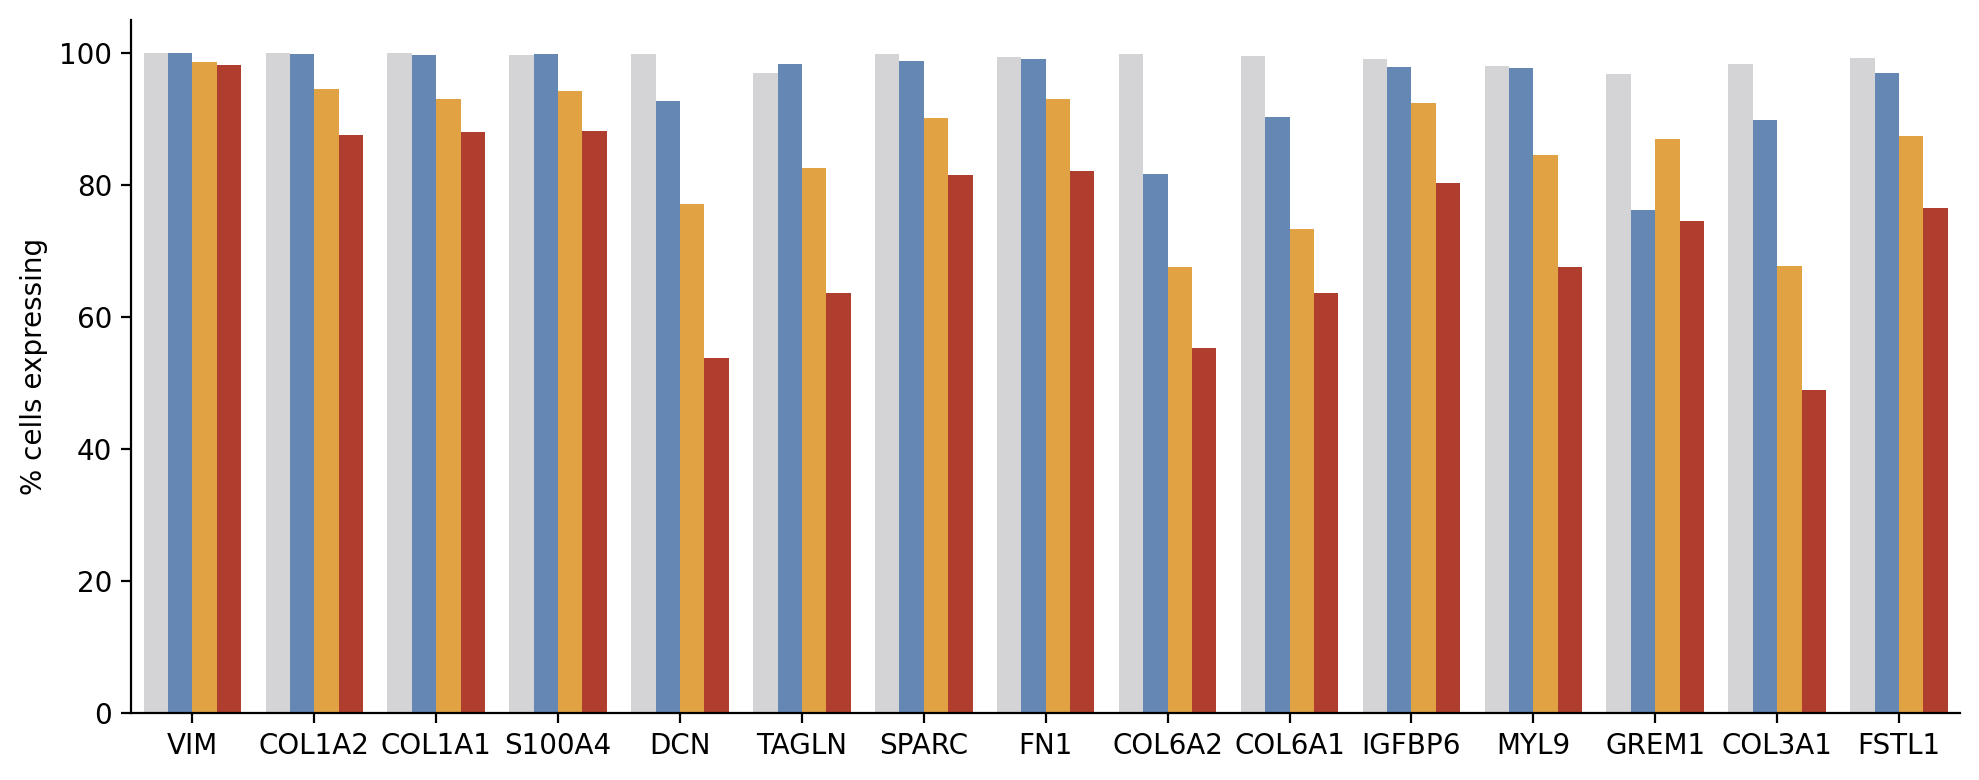

In [24]:
plt.figure(figsize=(10,4))

conditions = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
palette = ['#D3D4D8', '#5785C1', '#FBA72A', '#C52E19']

sns.barplot(
    data=pct_df, 
    x='gene', 
    y='pct_expressing', 
    hue='condition',
    palette=palette,
    hue_order=conditions,
    legend=False,
)

# plt.ylabel(f'% cells expressing above {int(q*100)}th percentile')
plt.ylabel(f'% cells expressing')
# plt.xticks(rotation=45)
plt.xlabel("")
# plt.legend(title='Condition')

sns.despine()
plt.tight_layout()
plt.show()

In [25]:
from scipy.stats import sem

expression_summary = []

for cond, cond_df in df1.groupby('pooled_condition', observed=True):
    for gene in genes_to_plot:
        expr_vals = cond_df[gene]
        mean_expr = expr_vals.mean()
        gene_sem = sem(expr_vals)
        expression_summary.append({
            'gene': gene,
            'condition': cond,
            'mean_expr': mean_expr,
            'sem': gene_sem
        })

expr_df = pd.DataFrame(expression_summary)

expr_df['mean_expr_scaled'] = expr_df.groupby('gene')['mean_expr'] \
    .transform(lambda x: (x - x.mean()) / x.std())

expr_df.head()

,gene,condition,mean_expr,sem,mean_expr_scaled
0,VIM,Control,3.817552,0.004521,0.699894
1,COL1A2,Control,3.652595,0.004965,1.201722
2,COL1A1,Control,3.508402,0.005863,1.411986
3,S100A4,Control,3.050069,0.009373,0.652363
4,DCN,Control,2.652652,0.007796,1.385849


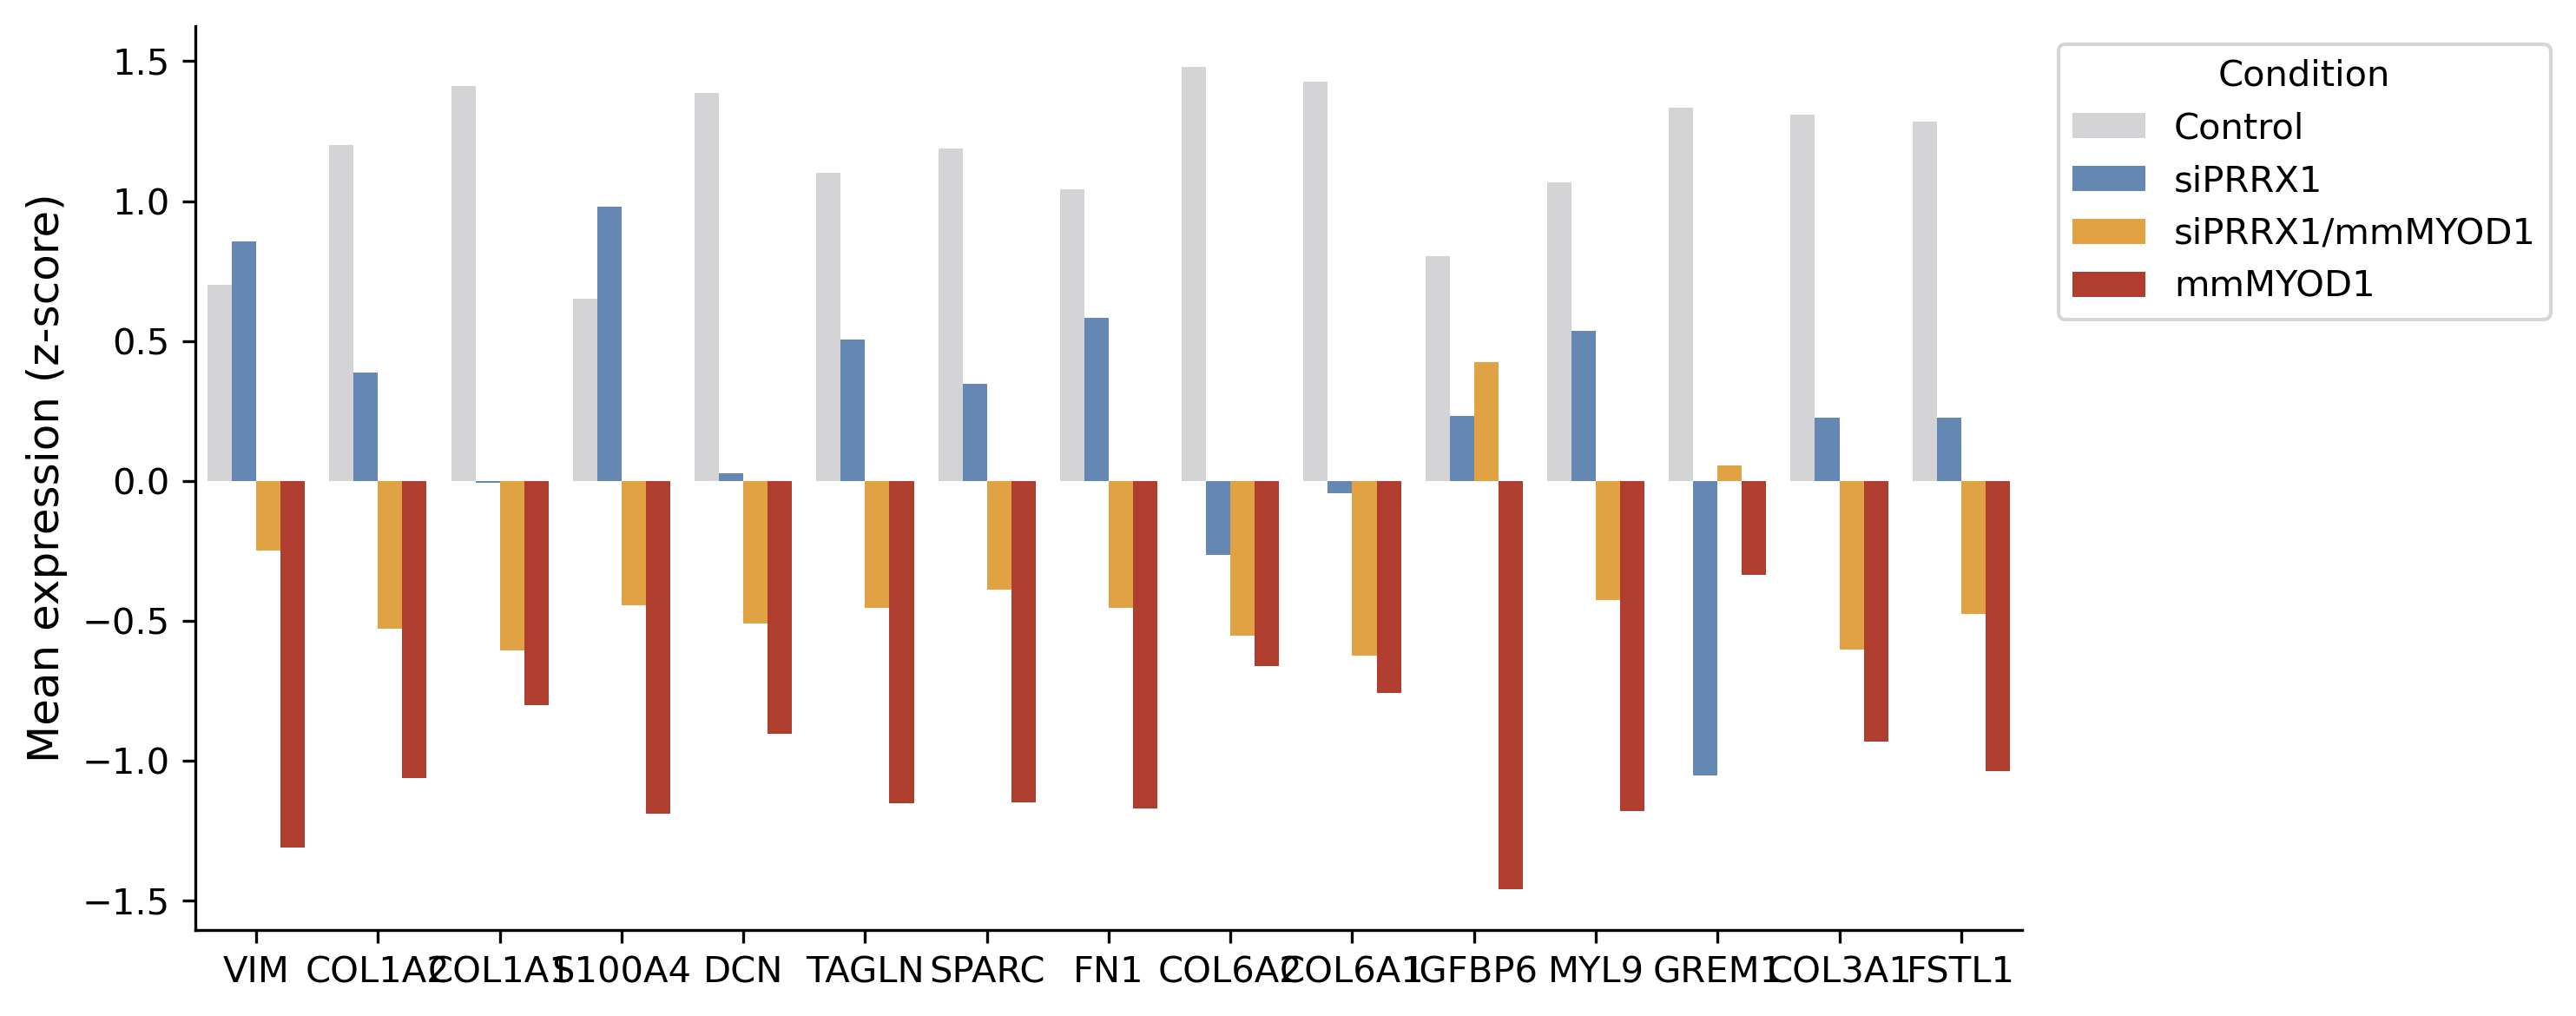

In [26]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

# Draw the barplot (no built-in CI, we'll add SEM manually)
bar_plot = sns.barplot(
    data=expr_df,
    x='gene',
    # y='mean_expr',
    y='mean_expr_scaled',
    hue='condition',
    palette=palette,
    hue_order=['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1'],
    ax=ax,
    capsize=0,       # No built-in errorbars
    errorbar=None    # Disable seaborn's automatic CI
)

# # --- Manually Add SEM Error Bars ---
# conditions = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
# genes = expr_df['gene'].unique()

# n_conditions = len(conditions)
# n_genes = len(genes)

# # Get the bar positions from the plot
# bar_containers = ax.containers  # One container per condition

# for cond_idx, (container, cond) in enumerate(zip(bar_containers, conditions)):
#     cond_data = expr_df[expr_df['condition'] == cond]

#     for bar, (_, row) in zip(container, cond_data.iterrows()):
#         x_pos = bar.get_x() + bar.get_width() / 2
#         y_pos = row['mean_expr']
#         sem_val = row['sem']

#         ax.errorbar(
#             x=x_pos,
#             y=y_pos,
#             yerr=sem_val,
#             fmt='none',         # No marker
#             color='black',
#             capsize=3,
#             linewidth=1.2
#         )

ax.set_xlabel('')
# ax.set_ylabel('Mean log-normalized expression', fontsize=12)
ax.set_ylabel('Mean expression (z-score)', fontsize=12)

ax.legend(title='Condition', bbox_to_anchor=(1.01, 1), loc='upper left')
# plt.xticks(rotation=45, ha='right')

# plt.ylim([0, 0.75])

sns.despine()
plt.tight_layout()
plt.show()

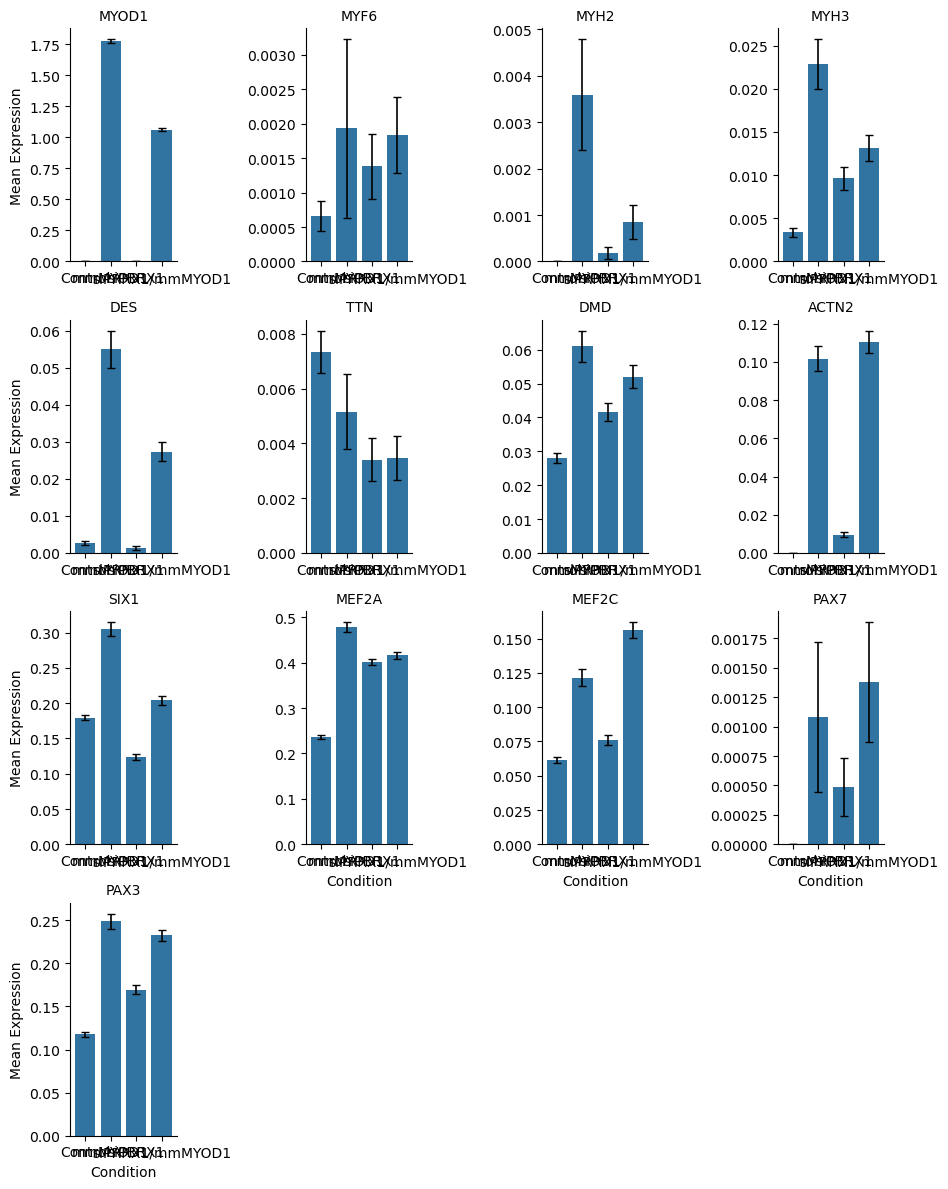

In [61]:
# def barplot_with_errorbars(data, **kwargs):
#     ax = plt.gca()
    
#     conditions = data['condition'].unique()
#     genes = data['gene'].unique()  # Should be 1 gene per facet
    
#     sns.barplot(
#         data=data,
#         x='condition',
#         y='mean_expr',
#         errorbar=None,
#         ax=ax
#     )
    
#     # Get all bar patches directly
#     bars = [p for p in ax.patches if p.get_width() > 0]
    
#     # Sort rows to match bar order
#     data_sorted = data.set_index('condition').loc[conditions].reset_index()
    
#     for bar, (_, row) in zip(bars, data_sorted.iterrows()):
#         ax.errorbar(
#             x=bar.get_x() + bar.get_width() / 2,
#             y=row['mean_expr'],
#             yerr=row['sem'],
#             fmt='none',
#             color='black',
#             capsize=3,
#             linewidth=1.2
#         )

# g = sns.FacetGrid(
#     expr_df,
#     col='gene',
#     col_wrap=4,
#     # hue='condition',
#     # palette='tab20',
#     sharey=False,
#     sharex=False,
#     height=3,
#     aspect=0.8
# )

# g.map_dataframe(barplot_with_errorbars)
# g.set_titles(col_template="{col_name}")
# g.set_axis_labels("Condition", "Mean Expression")
# plt.tight_layout()
# plt.show()

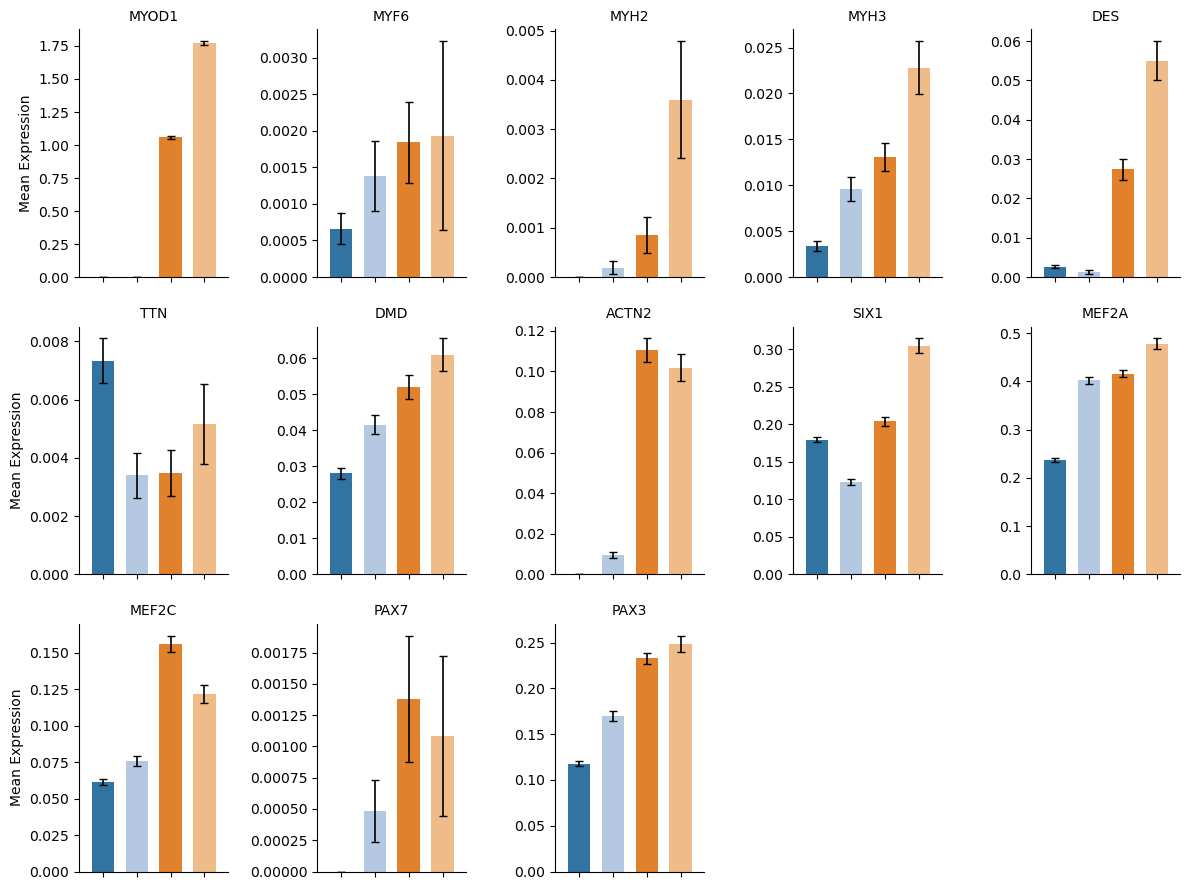

In [88]:
# # Define a color palette mapped to conditions
# conditions = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
# palette = sns.color_palette("tab20", n_colors=len(conditions))
# color_map = dict(zip(conditions, palette))

# def barplot_with_errorbars(data, **kwargs):
#     ax = plt.gca()
    
#     conditions_in_facet = data['condition'].unique()
#     bar_colors = [color_map[cond] for cond in conditions]
    
#     sns.barplot(
#         data=data,
#         x='condition',
#         y='mean_expr',
#         hue='condition',
#         order=conditions,
#         hue_order=conditions,
#         width=0.65,
#         legend=False,
#         errorbar=None,
#         palette=bar_colors,   # ← manually assign colors
#         ax=ax
#     )
    
#     bars = [p for p in ax.patches if p.get_width() > 0]
#     data_sorted = data.set_index('condition').loc[conditions].reset_index()
    
#     for bar, (_, row) in zip(bars, data_sorted.iterrows()):
#         ax.errorbar(
#             x=bar.get_x() + bar.get_width() / 2,
#             y=row['mean_expr'],
#             yerr=row['sem'],
#             fmt='none',
#             color='black',
#             capsize=3,
#             linewidth=1.2
#         )

        
# g = sns.FacetGrid(
#     expr_df,
#     col='gene',
#     col_wrap=5,
#     sharey=False,
#     sharex=False,
#     height=3,
#     aspect=0.8
# )

# g.map_dataframe(barplot_with_errorbars)
# g.set_titles(col_template="{col_name}")
# g.set_axis_labels("Condition", "Mean Expression")

# for ax in g.axes.flat:
#     ax.set_xticklabels([])
#     ax.set_xlabel('')
#     ax.margins(x=0.1)
    
# plt.tight_layout()
# g.fig.subplots_adjust(hspace=0.2, wspace=0.6)
# plt.show()

In [12]:
# legend_handles = [Patch(color=color_map[cond], label=cond) for cond in conditions]
# g.axes.flat[-1].legend(
#     handles=legend_handles,
#     title='Condition',
#     bbox_to_anchor=(1.5, 0.8),  # ← increase x to push further right
#     loc='lower right'
# )

def format_axis_scientific(ax):
    """
    If the y-axis max value has more than 3 digits (i.e., requires small decimals),
    rescale the ticks and add a multiplier label at the top of the axis.
    """
    ymax = ax.get_ylim()[1]
    
    # Find the order of magnitude
    if ymax == 0:
        return
    
    magnitude = np.floor(np.log10(abs(ymax)))
    
    # Only rescale if magnitude is <= -3 (e.g., 0.001, 0.0001, etc.)
    if magnitude <= -3:
        scale = 10 ** magnitude
        
        # Rescale the tick labels
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{x / scale:.2f}')
        )
        
        # Add multiplier label at the top of the y-axis
        ax.text(
            0, 1.02,                          # Just above the y-axis
            f'1e{int(magnitude)}',
            transform=ax.transAxes,
            fontsize=9,
            va='bottom',
            ha='left'
        )

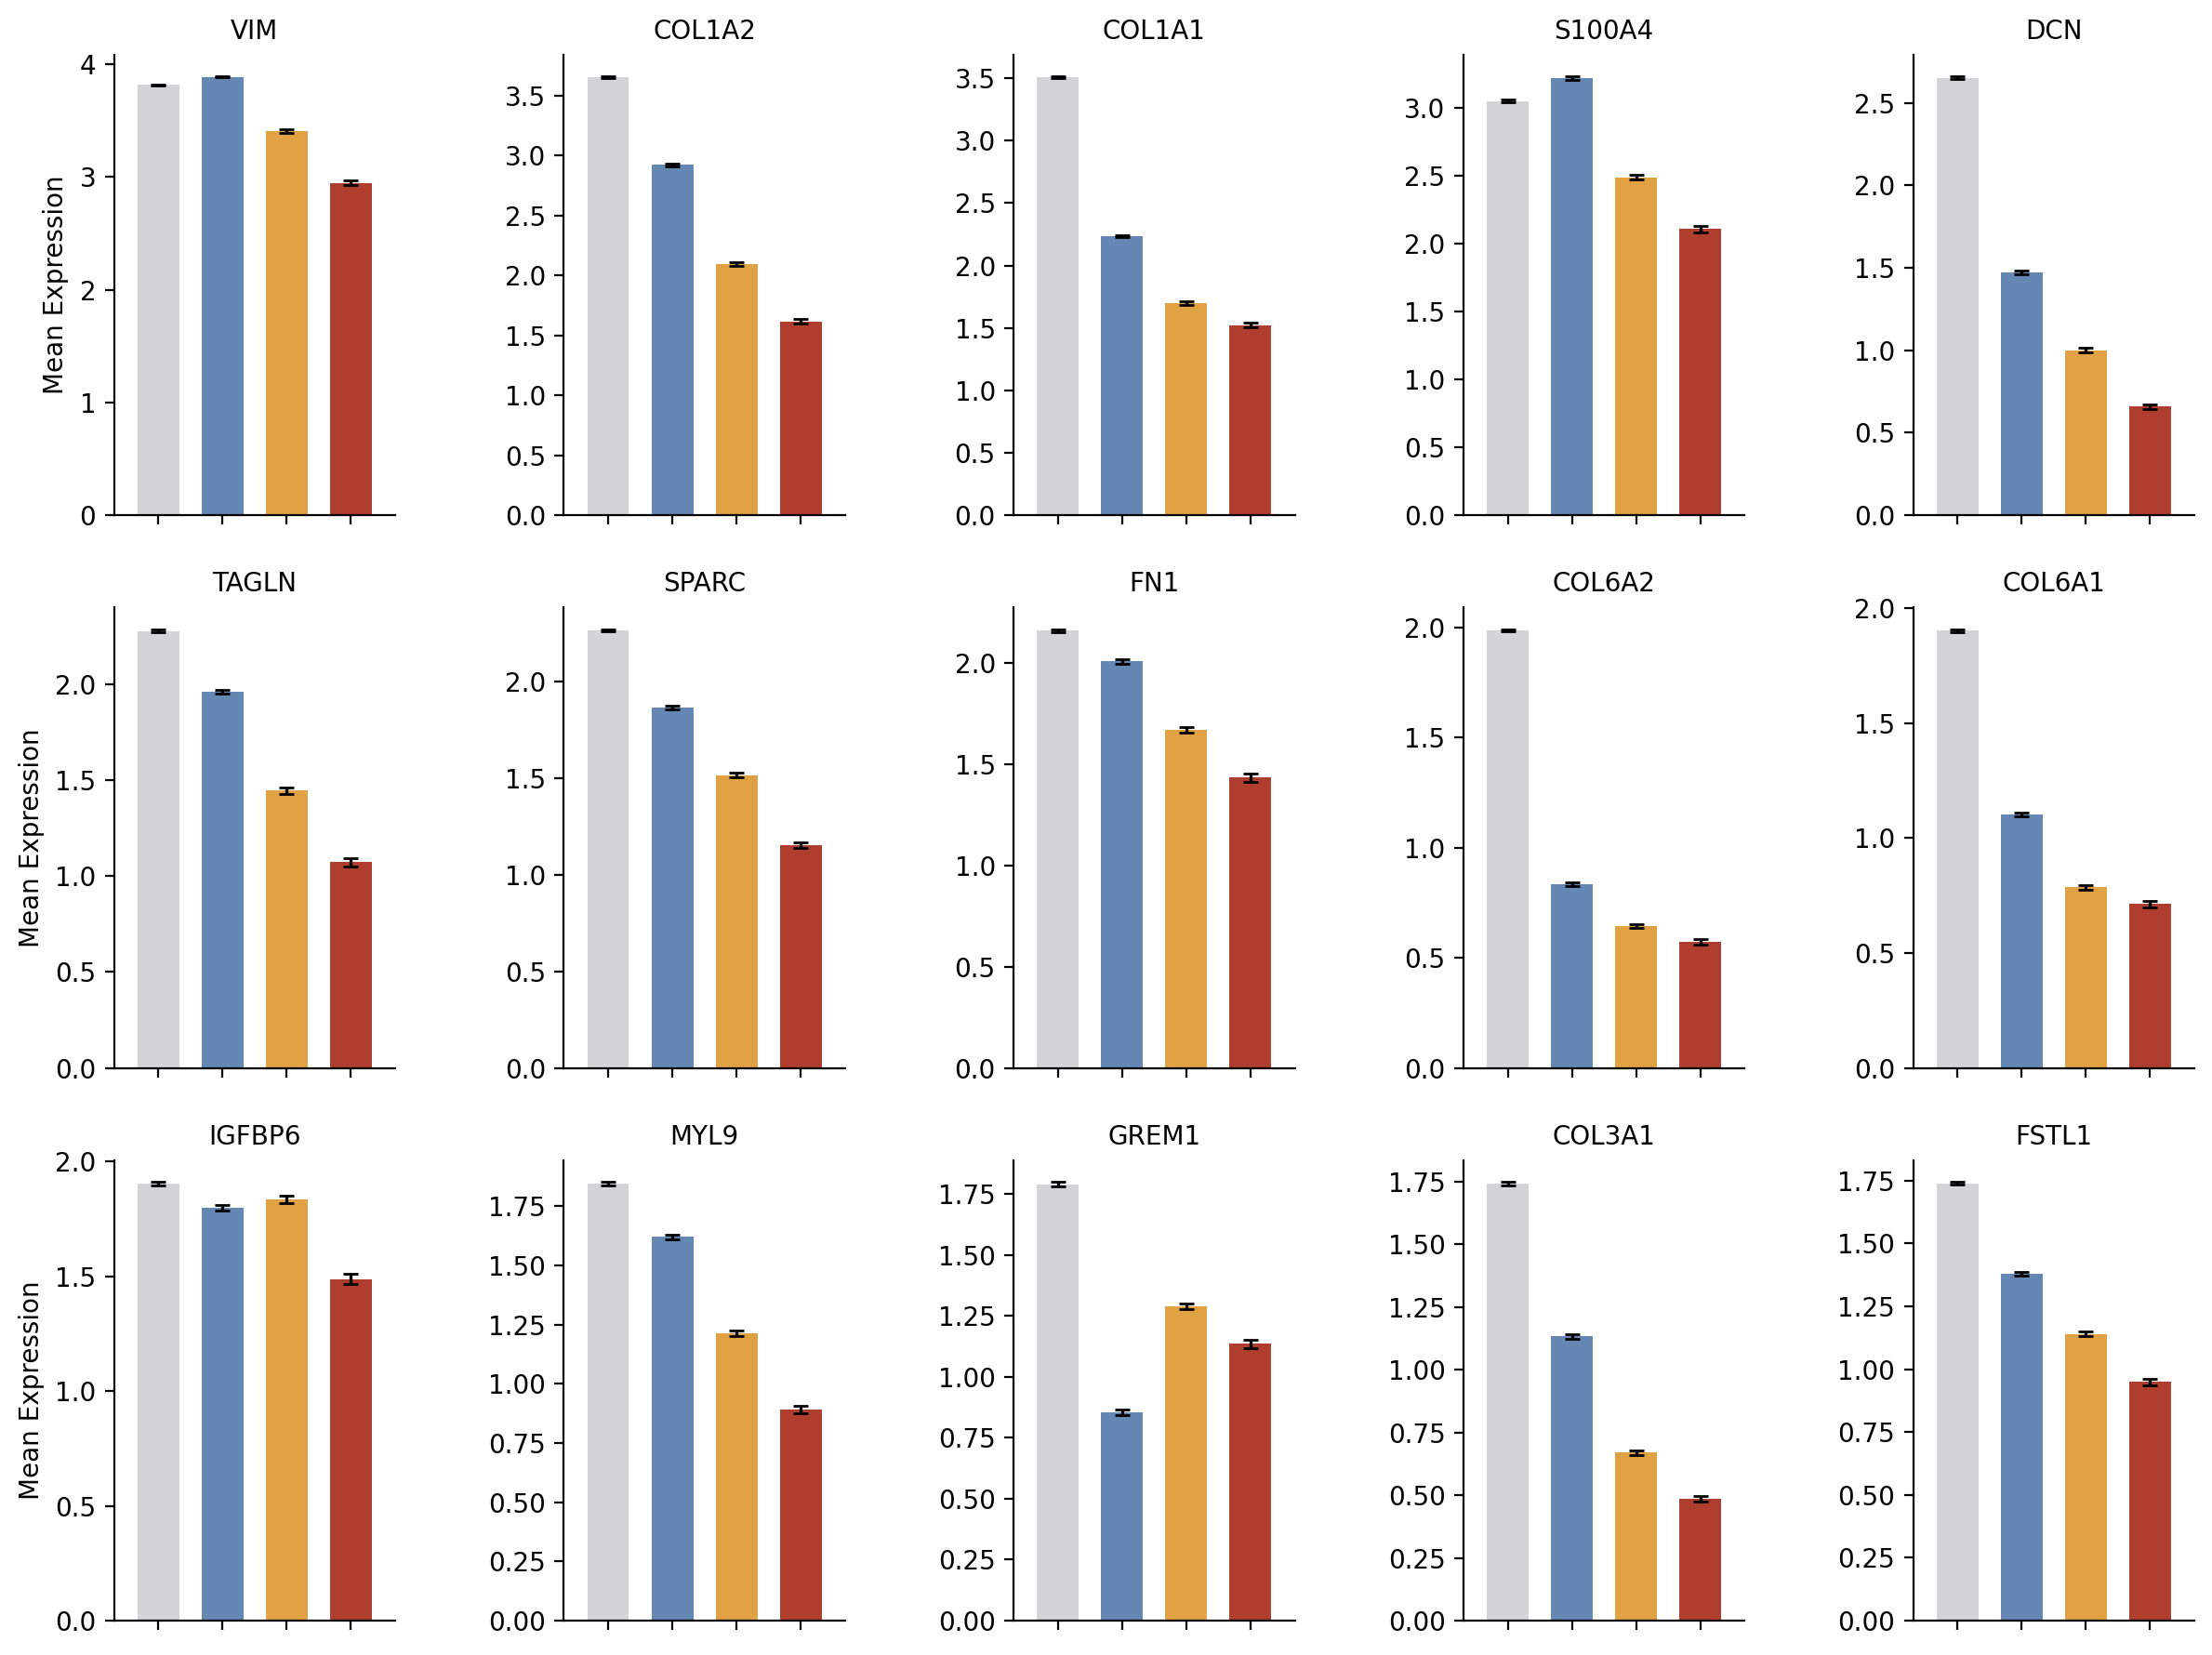

In [27]:
# Define a color palette mapped to conditions
conditions = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
palette = ['#D3D4D8', '#5785C1', '#FBA72A', '#C52E19']

# palette = sns.color_palette("tab20", n_colors=len(conditions))
color_map = dict(zip(conditions, palette))

def barplot_with_errorbars(data, **kwargs):
    ax = plt.gca()
    
    conditions_in_facet = data['condition'].unique()
    bar_colors = [color_map[cond] for cond in conditions]
    
    sns.barplot(
        data=data,
        x='condition',
        y='mean_expr',
        hue='condition',
        order=conditions,
        hue_order=conditions,
        width=0.65,
        legend=False,
        errorbar=None,
        palette=bar_colors,   # ← manually assign colors
        ax=ax
    )
    
    bars = [p for p in ax.patches if p.get_width() > 0]
    data_sorted = data.set_index('condition').loc[conditions].reset_index()
    
    for bar, (_, row) in zip(bars, data_sorted.iterrows()):
        ax.errorbar(
            x=bar.get_x() + bar.get_width() / 2,
            y=row['mean_expr'],
            yerr=row['sem'],
            fmt='none',
            color='black',
            capsize=3,
            linewidth=1.2
        )

        
g = sns.FacetGrid(
    expr_df,
    col='gene',
    # col_wrap=7,
    col_wrap=5,
    sharey=False,
    sharex=False,
    height=3,
    aspect=0.8
)

g.map_dataframe(barplot_with_errorbars)
g.set_titles(col_template="{col_name}", fontsize=20)
g.set_axis_labels("Condition", "Mean Expression")

for ax in g.axes.flat:
    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.margins(x=0.1)
    format_axis_scientific(ax)
    
plt.tight_layout()
g.fig.subplots_adjust(hspace=0.2, wspace=0.6)
plt.show()

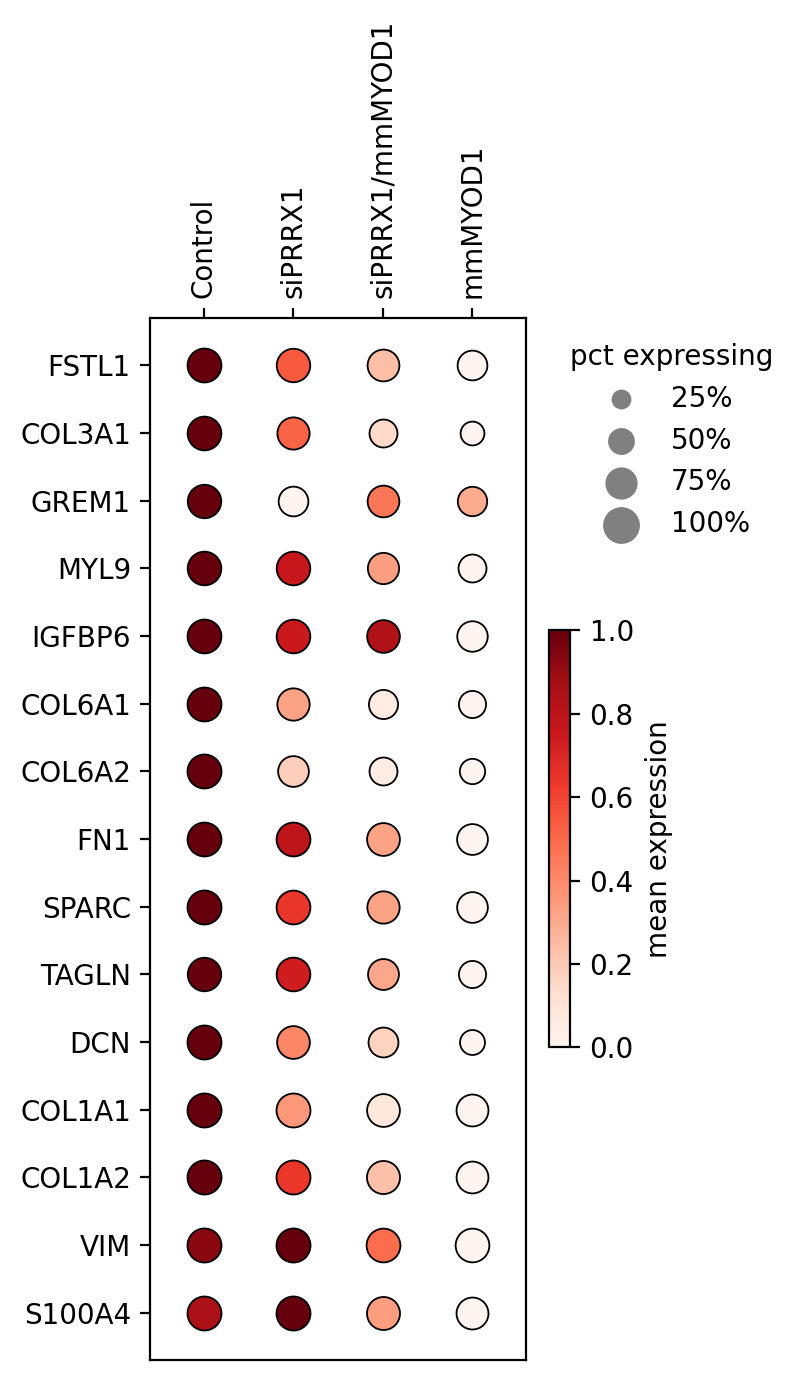

In [28]:
# # Myogenic
# genes_to_plot = [
#     'MYOD1', 'MYOG', 'MYF5', 'MYF6', 'MYH1', 'MYH2', 'MYH3', 'MYH7', 'MYH8', 'DES', 'TTN', 'DMD', 'TNN2', 'TNNT3', 'TNNI1', 
#     'ACTN2', 'SIX1', 'MEF2A', 'MEF2C', 'MEF2D', 'PAX7', 'PAX3', 'MSC', 
# ]


# genes_to_plot = [g for g in genes_to_plot if g in adata.var_names]



# groups = adata.obs['leiden_split'].unique()
# groups = adata.obs['pooled_condition'].unique()
groups = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
# groups = sorted(groups)

avg_expr = pd.DataFrame(index=genes_to_plot, columns=groups)
pct_expr = pd.DataFrame(index=genes_to_plot, columns=groups)

adata.X = adata.layers['log_norm'].copy()

for g in groups:
    # cells = adata.obs['leiden_split'] == g
    cells = adata.obs['pooled_condition'] == g
    data = adata[cells, genes_to_plot].X
    # If sparse matrix
    if not isinstance(data, np.ndarray):
        data = data.toarray()
    avg_expr[g] = data.mean(axis=0)
    pct_expr[g] = (data > 0).mean(axis=0) * 100

    
avg_expr_scaled = (avg_expr.T - avg_expr.min(axis=1)) / (avg_expr.max(axis=1) - avg_expr.min(axis=1))
avg_expr_scaled = avg_expr_scaled.T

# # sort for plotting
# # myogenic
# pct_expr = pct_expr.sort_values(by='mmMYOD1')
# genes = list(pct_expr.index)

# fibroblast
avg_expr_scaled = avg_expr_scaled.sort_values(by='Control')
genes = list(avg_expr_scaled.index)

# # Z-score by gene
# avg_expr = avg_expr.T   
# avg_expr_z = avg_expr.apply(scipy.stats.zscore, axis=0)
# avg_expr_z = avg_expr_z.T

# print(avg_expr_z.shape)
# avg_expr_z.head()  

cmap = 'Reds'
size_scale = 1.5

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 7
fig, ax = plt.subplots()

for i, gene in enumerate(genes):
    for j, cluster in enumerate(groups):
        size = float(pct_expr.loc[gene, cluster])*size_scale
        color = float(avg_expr_scaled.loc[gene, cluster])
        
        ax.scatter(
            x=j, 
            y=i, 
            s=size, 
            c=[color], 
            linewidths=0.65,
            edgecolors='k',
            cmap=cmap,
            vmin=0, 
            vmax=1, 
        )
        
ax.set_yticks(range(len(genes)))
ax.set_yticklabels(genes)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, rotation=90)
ax.xaxis.set_label_position('top') 
ax.xaxis.tick_top()
ax.set_xlabel('')

ax.margins(x=0.2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.05)
cbar.set_label('mean expression')


sizes = [25, 50, 75, 100]
markers = [plt.scatter([], [], s=s*size_scale, color='gray') for s in sizes]
labels = [f"{s}%" for s in sizes]

ax.legend(markers, labels, title="pct expressing", scatterpoints=1,
          frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

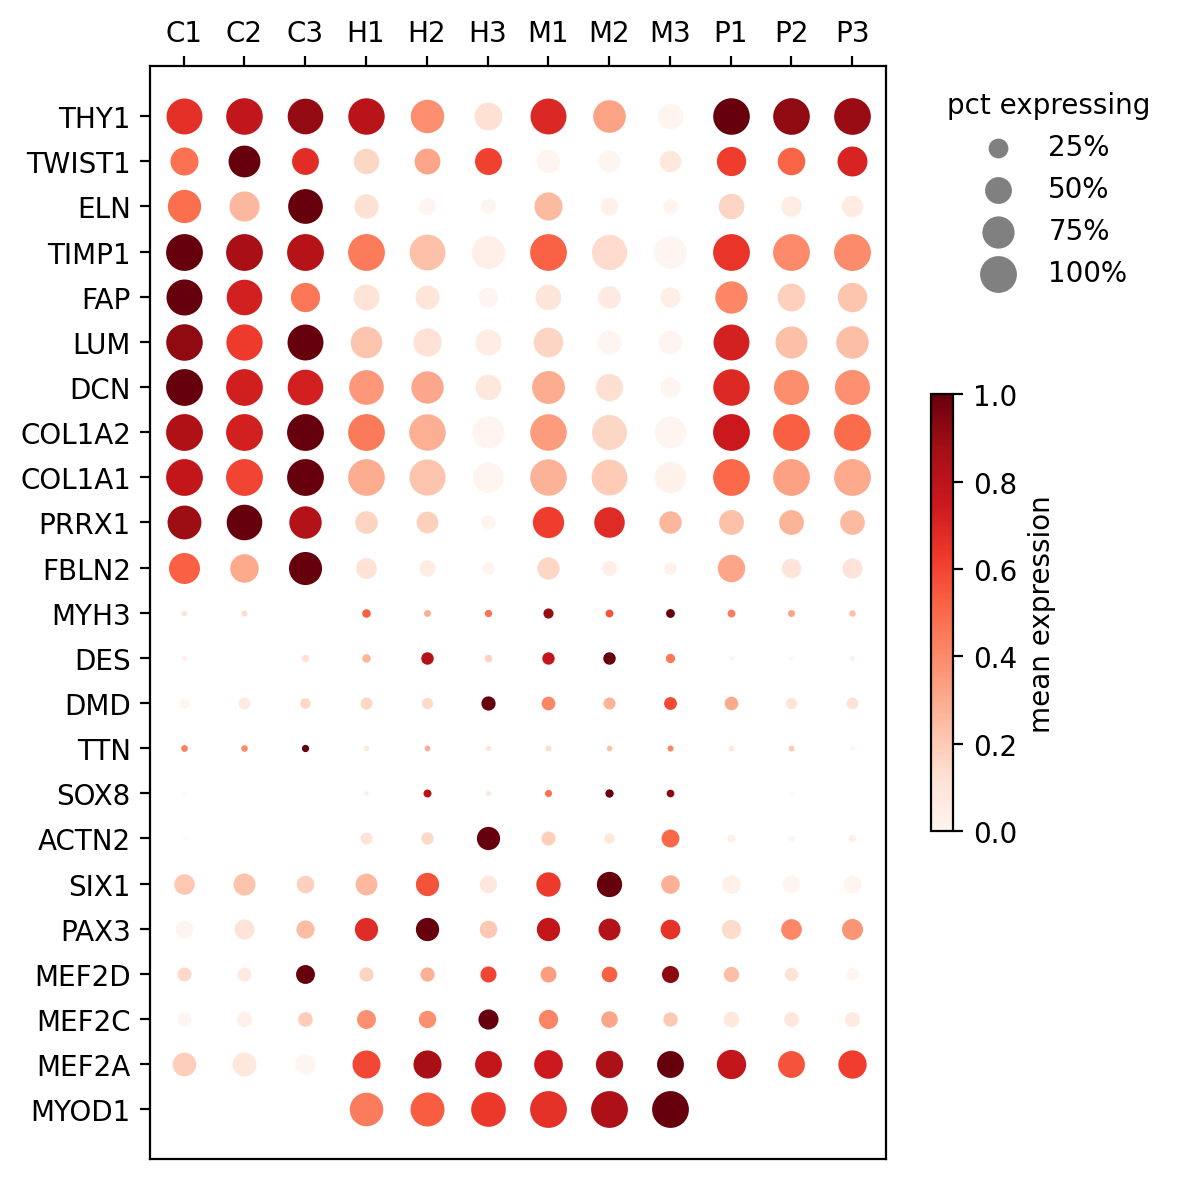

In [101]:
genes = [
    'MYOD1', 'MEF2A', 'MEF2C', 'MEF2D', 'PAX3', 'SIX1', 'ACTN2',
    'SOX8', 'TNNT3', 'TNNI1', 'TTN', 'DMD', 'DES', 'MYH3',
    'FBLN2',
    'PRRX1', 'COL1A1', 'COL1A2', 'DCN', 'LUM', 'FAP', 'TIMP1', 'ELN', 'TWIST1', 'THY1', 
]

genes_to_plot = [g for g in genes if g in adata.var_names]

groups = adata.obs['leiden_split'].unique()
# groups = adata.obs['pooled_condition'].unique()
groups = sorted(groups)

avg_expr = pd.DataFrame(index=genes_to_plot, columns=groups)
pct_expr = pd.DataFrame(index=genes_to_plot, columns=groups)

adata.X = adata.layers['log_norm'].copy()

for g in groups:
    cells = adata.obs['leiden_split'] == g
    # cells = adata.obs['pooled_condition'] == g
    data = adata[cells, genes_to_plot].X
    # If sparse matrix
    if not isinstance(data, np.ndarray):
        data = data.toarray()
    avg_expr[g] = data.mean(axis=0)
    pct_expr[g] = (data > 0).mean(axis=0) * 100

    
avg_expr_scaled = (avg_expr.T - avg_expr.min(axis=1)) / (avg_expr.max(axis=1) - avg_expr.min(axis=1))
avg_expr_scaled = avg_expr_scaled.T
    
# # Z-score by gene
# avg_expr = avg_expr.T   
# avg_expr_z = avg_expr.apply(scipy.stats.zscore, axis=0)
# avg_expr_z = avg_expr_z.T

# print(avg_expr_z.shape)
# avg_expr_z.head()  

cmap = 'Reds'
size_scale = 1.5

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 6
fig, ax = plt.subplots()

for i, gene in enumerate(genes_to_plot):
    for j, cluster in enumerate(groups):
        size = float(pct_expr.loc[gene, cluster])*size_scale
        color = float(avg_expr_scaled.loc[gene, cluster])
        
        ax.scatter(
            x=j, 
            y=i, 
            s=size, 
            c=[color], 
            cmap=cmap,
            vmin=0, 
            vmax=1, 
        )
        
ax.set_yticks(range(len(genes_to_plot)))
ax.set_yticklabels(genes_to_plot)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups)
ax.xaxis.set_label_position('top') 
ax.xaxis.tick_top()
ax.set_xlabel('')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.05)
cbar.set_label('mean expression')


sizes = [25, 50, 75, 100]
markers = [plt.scatter([], [], s=s*size_scale, color='gray') for s in sizes]
labels = [f"{s}%" for s in sizes]

ax.legend(markers, labels, title="pct expressing", scatterpoints=1,
          frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

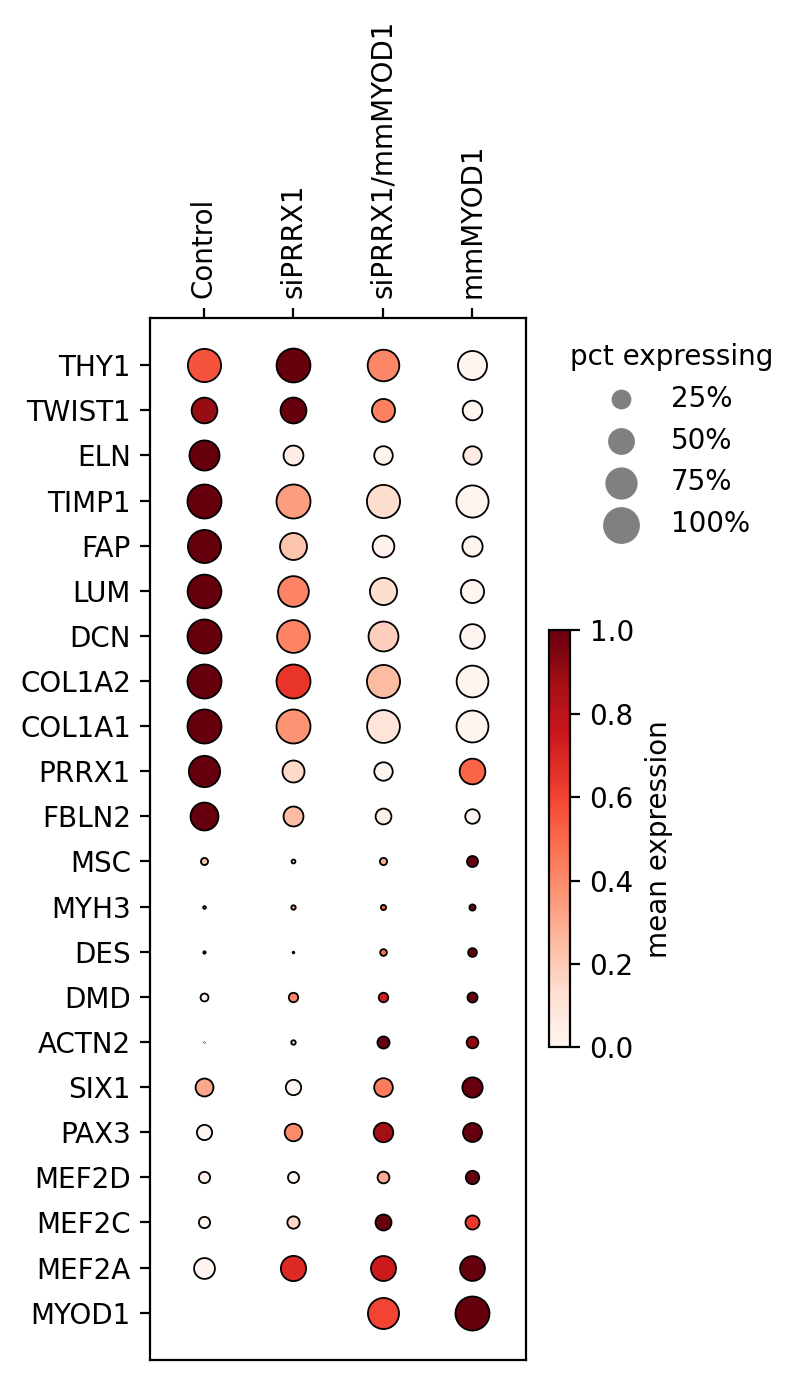

In [116]:
genes = [
    'MYOD1', 'MEF2A', 'MEF2C', 'MEF2D', 'PAX3', 'SIX1', 'ACTN2',
    'TNNT3', 'TNNI1', 'DMD', 'DES', 'MYH3', 'MSC', # 'TTN', 'SOX8',
    'FBLN2',
    'PRRX1', 'COL1A1', 'COL1A2', 'DCN', 'LUM', 'FAP', 'TIMP1', 'ELN', 'TWIST1', 'THY1', 
]

genes_to_plot = [g for g in genes if g in adata.var_names]

# groups = adata.obs['leiden_split'].unique()
# groups = adata.obs['pooled_condition'].unique()
groups = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
# groups = sorted(groups)

avg_expr = pd.DataFrame(index=genes_to_plot, columns=groups)
pct_expr = pd.DataFrame(index=genes_to_plot, columns=groups)

adata.X = adata.layers['log_norm'].copy()

for g in groups:
    # cells = adata.obs['leiden_split'] == g
    cells = adata.obs['pooled_condition'] == g
    data = adata[cells, genes_to_plot].X
    # If sparse matrix
    if not isinstance(data, np.ndarray):
        data = data.toarray()
    avg_expr[g] = data.mean(axis=0)
    pct_expr[g] = (data > 0).mean(axis=0) * 100

    
avg_expr_scaled = (avg_expr.T - avg_expr.min(axis=1)) / (avg_expr.max(axis=1) - avg_expr.min(axis=1))
avg_expr_scaled = avg_expr_scaled.T
    
# # Z-score by gene
# avg_expr = avg_expr.T   
# avg_expr_z = avg_expr.apply(scipy.stats.zscore, axis=0)
# avg_expr_z = avg_expr_z.T

# print(avg_expr_z.shape)
# avg_expr_z.head()  

cmap = 'Reds'
size_scale = 1.5

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 7
fig, ax = plt.subplots()

for i, gene in enumerate(genes_to_plot):
    for j, cluster in enumerate(groups):
        size = float(pct_expr.loc[gene, cluster])*size_scale
        color = float(avg_expr_scaled.loc[gene, cluster])
        
        ax.scatter(
            x=j, 
            y=i, 
            s=size, 
            c=[color], 
            linewidths=0.65,
            edgecolors='k',
            cmap=cmap,
            vmin=0, 
            vmax=1, 
        )
        
ax.set_yticks(range(len(genes_to_plot)))
ax.set_yticklabels(genes_to_plot)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, rotation=90)
ax.xaxis.set_label_position('top') 
ax.xaxis.tick_top()
ax.set_xlabel('')

ax.margins(x=0.2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.05)
cbar.set_label('mean expression')


sizes = [25, 50, 75, 100]
markers = [plt.scatter([], [], s=s*size_scale, color='gray') for s in sizes]
labels = [f"{s}%" for s in sizes]

ax.legend(markers, labels, title="pct expressing", scatterpoints=1,
          frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

# Radar plots

In [14]:
print(len(fib_genes))
print(len(myo_genes))
print(len(unique_to_fib))
print(len(unique_to_myo))

220
210
176
166


In [23]:
groups = ['C1','C2', 'C3', 'P1', 'P2', 'P3', 'M1', 'M2', 'M3', 'H1', 'H2', 'H3']

## all markers
# fib_genes = fib_genes.copy()
# muscle_genes = myo_genes.copy()

## unique to each group
fib_genes = unique_to_fib.copy()
muscle_genes = unique_to_myo.copy()


genes_to_plot = fib_genes + muscle_genes

avg_expr = pd.DataFrame(index=genes_to_plot, columns=groups)
pct_expr = pd.DataFrame(index=genes_to_plot, columns=groups)

adata.X = adata.layers['log_norm'].copy()

for g in groups:
    cells = adata.obs['leiden_split'] == g
    data = adata[cells, genes_to_plot].X
    if not isinstance(data, np.ndarray):
        data = data.toarray()
    avg_expr[g] = data.mean(axis=0)
    pct_expr[g] = (data > 0).mean(axis=0) * 100

# Z-score by gene
avg_expr = avg_expr.T   
avg_expr_z = avg_expr.apply(zscore, axis=0)
avg_expr_z = avg_expr_z.T

print(avg_expr_z.shape)
avg_expr_z.head() 


tmp = avg_expr_z.reset_index(names='gene_name')
tmp['marker'] = ['fibroblast'] * len(fib_genes) + ['myogenic'] * len(muscle_genes)
col_order = ['marker', 'gene_name', 'C1','C2', 'C3', 'P1', 'P2', 'P3', 'M1', 'M2', 'M3', 'H1', 'H2', 'H3']
tmp = tmp[col_order]

tmp.head()

(342, 12)


,marker,gene_name,C1,C2,C3,P1,P2,P3,M1,M2,M3,H1,H2,H3
0,fibroblast,PTCH1,-0.566263,-0.600979,-0.715488,1.080963,-0.129023,0.449741,2.777432,-0.397987,-0.522527,-1.043788,-0.419679,0.087597
1,fibroblast,TAGLN,1.300436,0.999928,0.265489,0.499827,0.818316,0.539074,-1.914019,0.287355,-1.488638,0.387187,-0.357572,-1.337387
2,fibroblast,ZEB2,-0.481666,-0.422253,0.128748,-0.814728,-0.579434,-0.700692,0.237681,-0.350247,2.093131,-0.877989,-0.379103,2.146551
3,fibroblast,TNXB,-0.817222,-0.723565,0.424172,-0.341318,-0.185773,-0.469756,-0.628805,-0.536211,2.939816,-0.517392,0.042379,0.813677
4,fibroblast,CYBRD1,0.753579,1.377079,1.493260,0.053645,0.680827,0.276484,-0.778817,-0.130200,-1.665112,0.055159,-0.307810,-1.808094


In [24]:
tmp_melt = pd.melt(
    tmp, 
    id_vars=['marker', 'gene_name'],
    value_vars=groups,
    var_name='cluster',
    value_name='avg_expr_z',
)

overall = (tmp_melt.groupby(['marker', 'cluster'], as_index=False)['avg_expr_z'].mean())
overall = overall.pivot(index='marker', columns='cluster', values='avg_expr_z')
overall.columns.name = None
overall

,C1,C2,C3,H1,H2,H3,M1,M2,M3,P1,P2,P3
marker,,,,,,,,,,,,
fibroblast,0.113273,0.421974,0.313839,-0.165754,0.036016,-0.232365,-0.333814,0.040676,-0.028262,-0.200286,0.230069,-0.195367
myogenic,-0.295331,-0.148062,-0.505195,-0.225670,0.119767,0.133857,0.420849,0.288280,0.697201,-0.293027,0.078219,-0.270889


In [25]:
tmp1 = pct_expr.reset_index(names='gene_name')
tmp1['marker'] = ['fibroblast'] * len(fib_genes) + ['myogenic'] * len(muscle_genes)
col_order = ['marker', 'gene_name', 'C1','C2', 'C3', 'P1', 'P2', 'P3', 'M1', 'M2', 'M3', 'H1', 'H2', 'H3']
tmp1 = tmp1[col_order]

tmp1_melt = pd.melt(
    tmp1, 
    id_vars=['marker', 'gene_name'],
    value_vars=groups,
    var_name='cluster',
    value_name='pct_expr',
)

overall_pct = (tmp1_melt.groupby(['marker', 'cluster'], as_index=False)['pct_expr'].mean())
overall_pct = overall_pct.pivot(index='marker', columns='cluster', values='pct_expr')
overall_pct.columns.name = None
overall_pct

,C1,C2,C3,H1,H2,H3,M1,M2,M3,P1,P2,P3
marker,,,,,,,,,,,,
fibroblast,37.624442,36.829653,37.611915,30.984678,29.777912,23.313718,21.613110,31.448706,22.119342,29.116769,35.339882,30.921533
myogenic,24.482778,22.678634,21.449434,24.326685,24.547855,21.405981,21.864593,26.243937,22.457732,22.138940,26.162927,23.884443


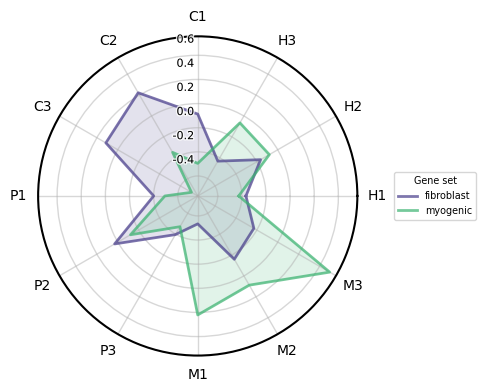

In [26]:
# Radar plot
cluster_order = ['H1', 'H2', 'H3', 'C1','C2', 'C3', 'P1', 'P2', 'P3', 'M1', 'M2', 'M3']

overall_reordered = overall[cluster_order]
num_clusters = len(cluster_order)
angles = np.linspace(0, 2 * np.pi, num_clusters, endpoint=False).tolist()
angles += angles[:1]   # Close the plot

# Plot
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

colors = ['darkslateblue', 'mediumseagreen']

for i, (idx, row) in enumerate(overall_reordered.iterrows()):
    # values = row.values.tolist()
    values = row.tolist()
    values += values[:1]
    ax.plot(
        angles, values, 
        linewidth=2, 
        linestyle='-', 
        color=colors[i], 
        label=str(idx),
        alpha=0.7
    )
    ax.fill(
        angles, values, 
        color=colors[i], 
        alpha=0.15
    )

ax.set_xticks(angles[:-1])    
ax.set_xticklabels(cluster_order)
ax.grid(True, linestyle='-', linewidth=1, alpha=0.5)

ax.set_yticklabels([])
r_ticks = ax.get_yticks()
r_min, r_max = ax.get_ylim()
angle_rad = np.deg2rad(90)
pad = ' '
for r in r_ticks:
    if r_min < r < r_max:
        txt = ax.text(angle_rad, r+0.13, f"{r:.1f}{pad}", va='center', ha='right', fontsize=8)
        txt.set_path_effects([path_effects.withStroke(linewidth=2, foreground='white', alpha=0.8)])

        
# ax.set_ylim(r_min, 1.5)
ax.spines['polar'].set_color('k')
ax.spines['polar'].set_linewidth(1.5)

ax.legend(
    title='Gene set',
    loc='center left',
    bbox_to_anchor=(1.1, 0.5),
    fontsize='x-small',
    title_fontsize='x-small',
)

plt.tight_layout()
plt.show()

In [27]:
adata.X = adata.layers['log_norm'].copy()

genes = ['MYOD1', 'CDKN1A', 'CDKN1B', 'CDK2']

mdata = adata[:, genes].copy()
print(mdata.shape)

X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

df = pd.DataFrame(
        X,
        index=mdata.obs_names,
        columns=mdata.var_names,
    )

df = df.reset_index(names='cell_id')
print(df.shape)
df.head()


tmp = adata.obs[['pooled_condition', 'leiden_split', 'phase']].copy()

tmp = tmp.reset_index(names='cell_id')


df1 = pd.merge(df, tmp, how='left', on='cell_id')
print(df1.shape)
df1.head()

(16296, 4)
(16296, 5)
(16296, 8)


,cell_id,MYOD1,CDKN1A,CDKN1B,CDK2,pooled_condition,leiden_split,phase
0,AAACCAAAGCAACTGC_hybrid,2.306209,0.000000,0.426279,0.426279,siPRRX1/mmMYOD1,H1,G2M
1,AAACCAAAGTAGGGCA_hybrid,1.635624,1.120481,0.000000,0.709594,mmMYOD1,M1,S
2,AAACCAAAGTCTAGGC_hybrid,1.135698,1.135698,0.301751,0.000000,siPRRX1/mmMYOD1,H1,G1
3,AAACCATTCACGTAAT_hybrid,0.000000,0.000000,0.709331,0.000000,siPRRX1,P1,G2M
4,AAACCATTCAGGCAGA_hybrid,0.000000,1.154519,0.735367,0.433809,siPRRX1,P1,G2M


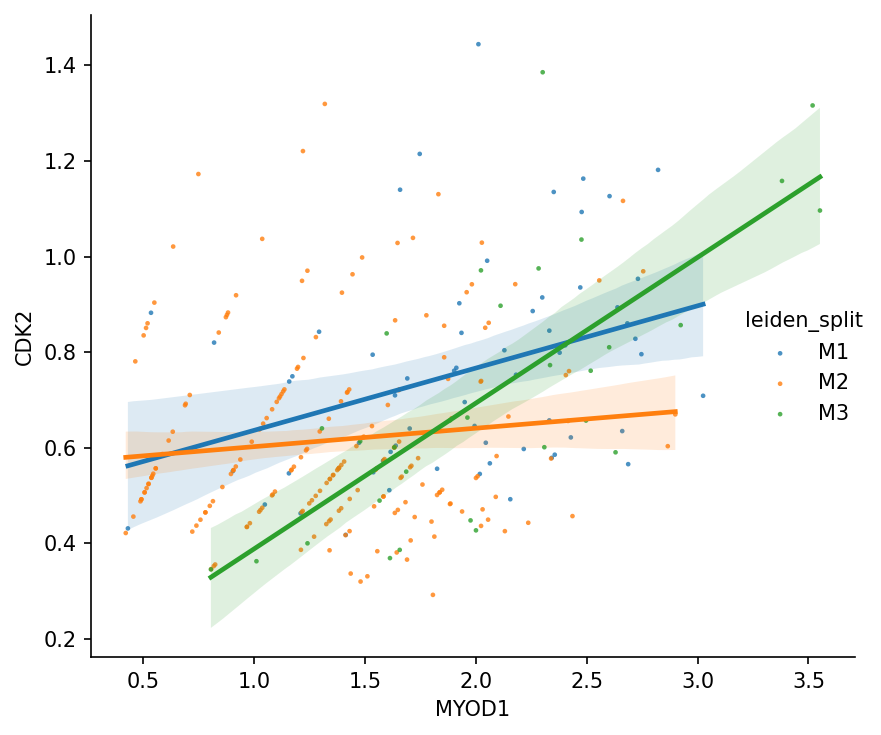

In [40]:
conds_to_plot = ['M1', 'M2', 'M3']

genes_to_plot = [
    'MYOD1',
    'CDK2',
]

tmp = df1[df1['leiden_split'].isin(conds_to_plot)].copy()
tmp['leiden_split'] = tmp['leiden_split'].astype(str)

# drop rows where either gene is 0
tmp = tmp[(tmp[genes_to_plot] > 0).all(axis=1)]


plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sns.lmplot(
    data=tmp,
    x='MYOD1',
    y=genes_to_plot[1],
    hue='leiden_split',
    scatter_kws={'s': 5, 'ec': 'none'},
)
# sns.kdeplot(
#     data=tmp,
#     x='MYOD1',
#     y='CDKN1A',
#     hue='leiden_split',
#     fill=True,
#     alpha=0.5,
# )


plt.tight_layout()
plt.show()

In [ ]:
conds_to_plot = ['M1', 'M2', 'M3']
axes = axes.flatten()

fig, axes = plt.subplots(1, len(conds_to_plot), figsize=(8,4), dpi=150)


for i cond in enumerate(conds_to_plot):
    ax = axes[i]
    
    


# Apoptosis / Senescence / Quiescence

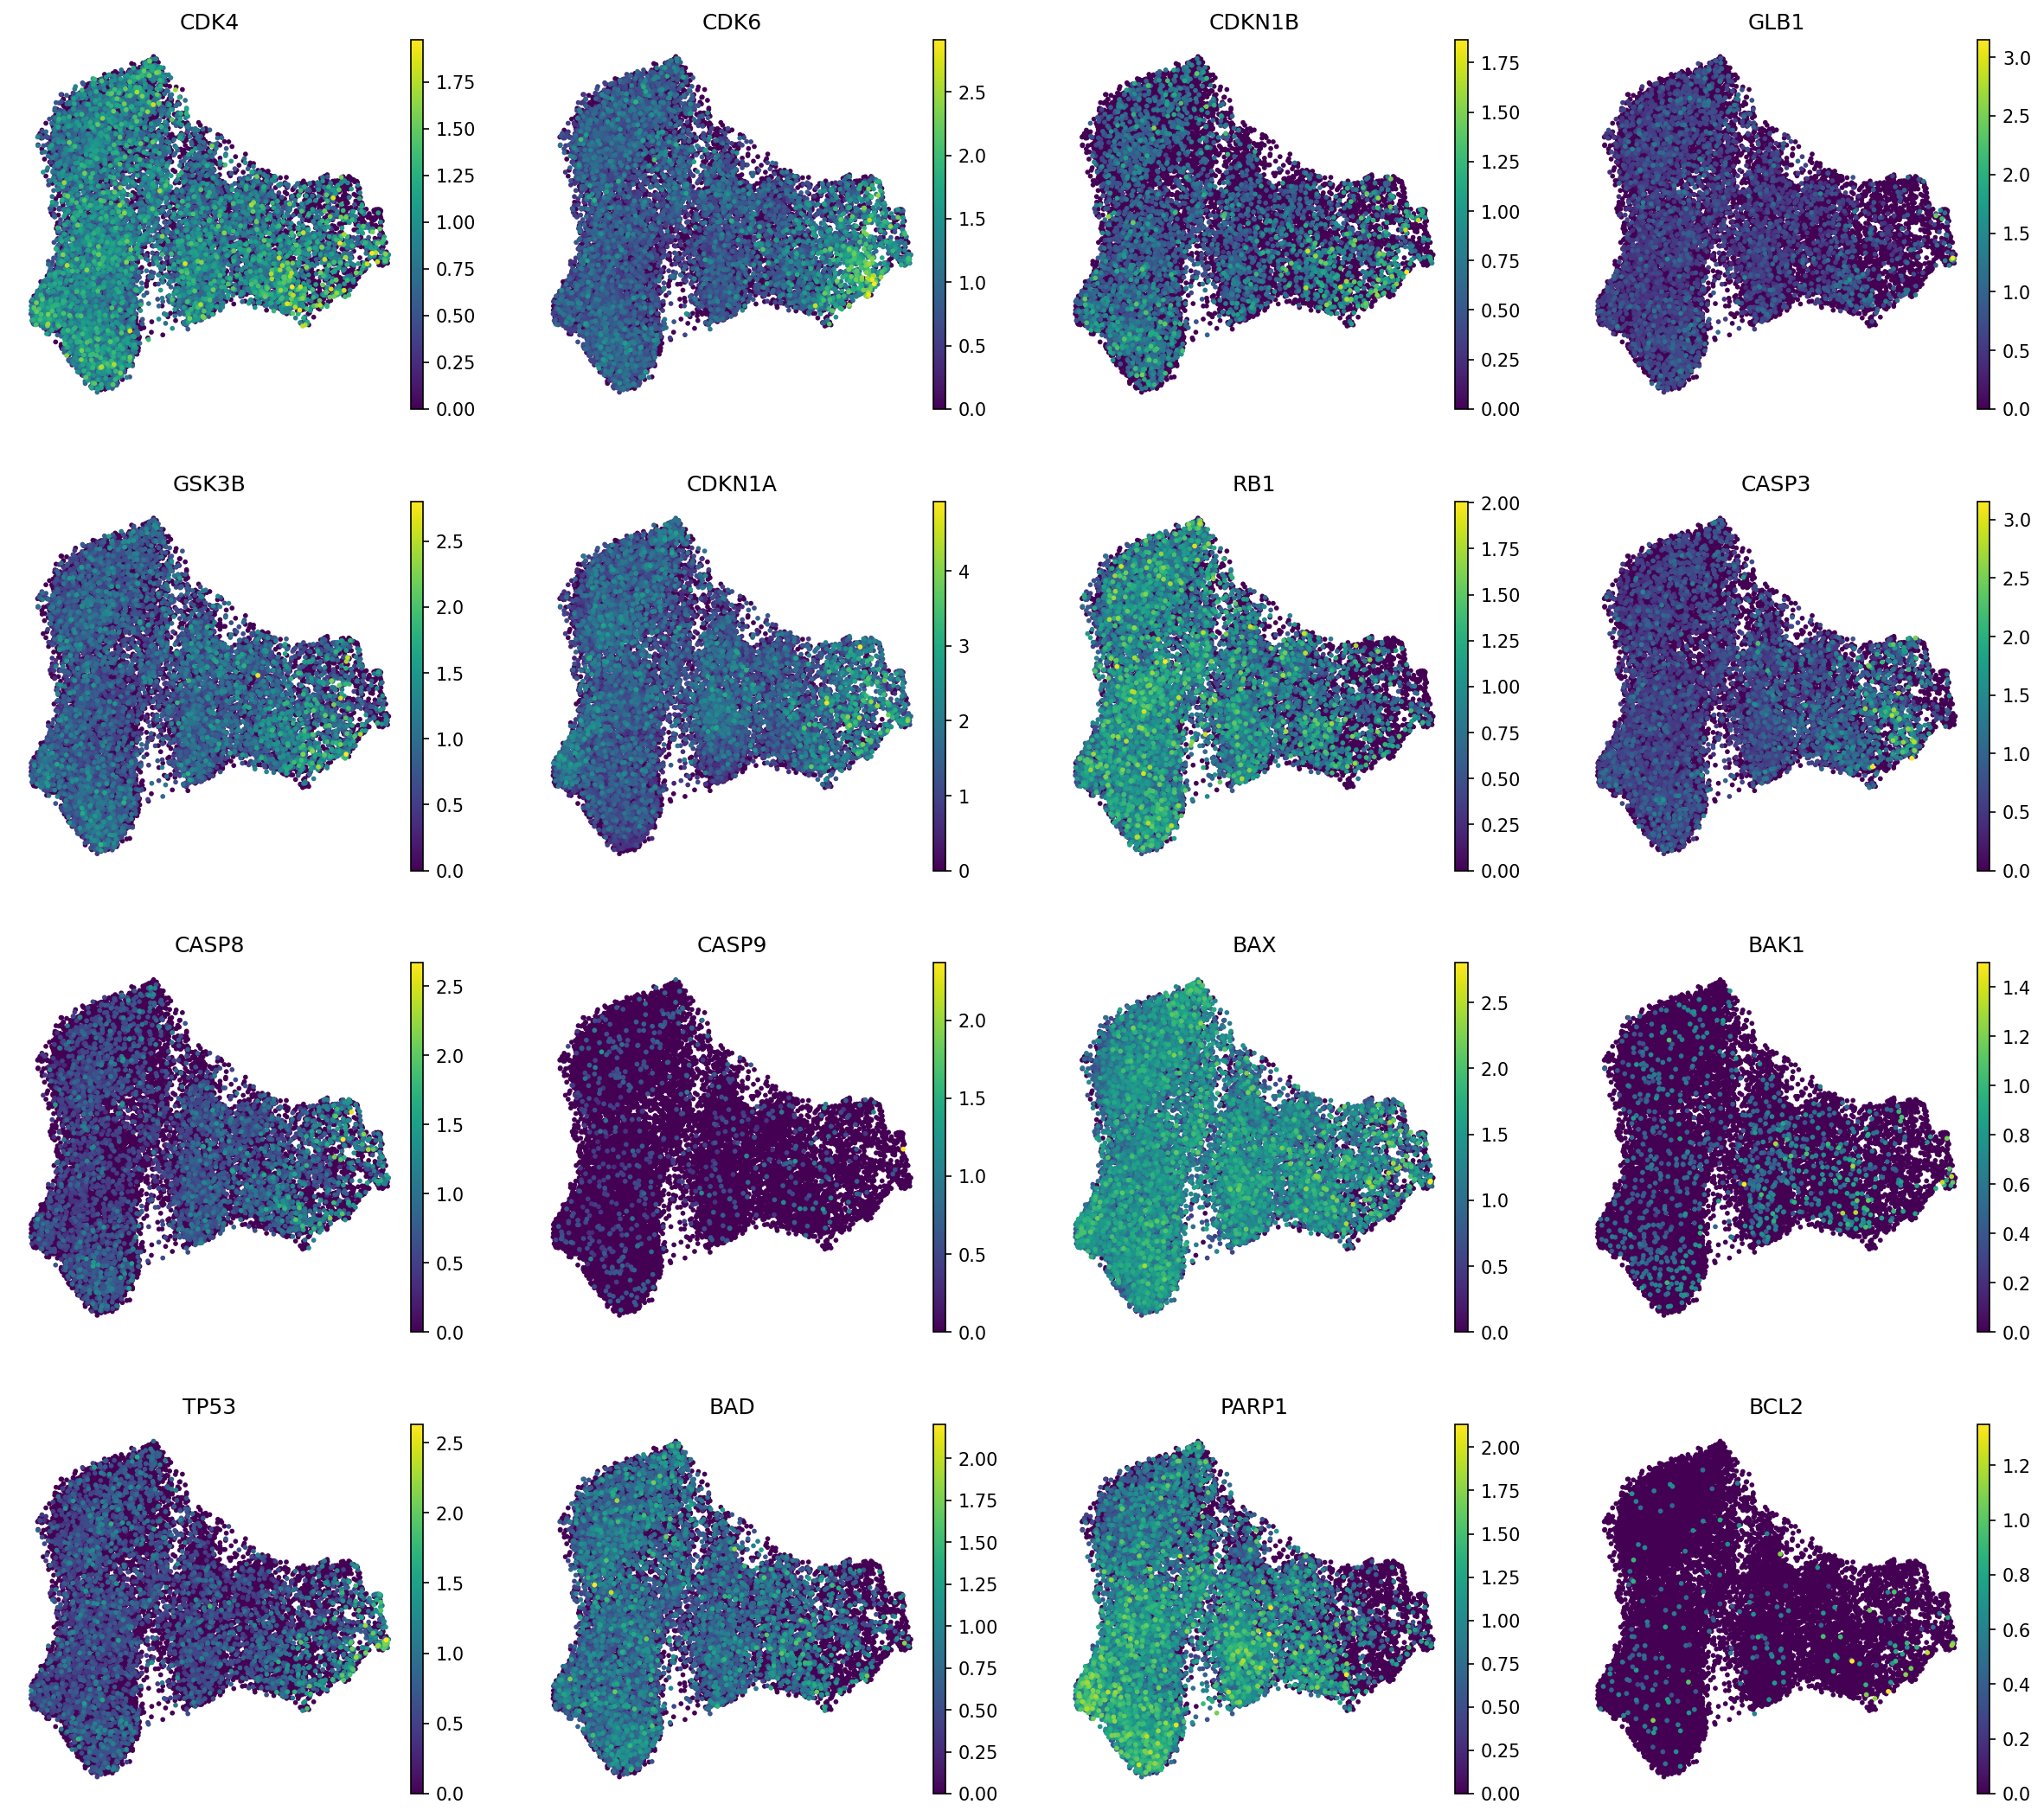

In [24]:
genes_to_plot = [
    'CDK4', 'CDK6', 'CDKN1B', 'GLB1', 'GSK3B', # senescence
    
    'CDKN1A', 'RB1', # quiescence
    
    'CASP3', 'CASP8', 'CASP9', 'BAX', 'BAK1', 'TP53', 'BAD', 'PARP1', 'BCL2',# apoptosis
]

genes_to_plot = [g for g in genes_to_plot if g in adata.var_names]

sc.pl.umap(
    adata,
    color=genes_to_plot,
    size=30,
    ncols=4,
    frameon=False,
    alpha=1,
    layer='log_norm',
)

# Groups

In [3]:
# try to identify cycling fibroblast-like, cycling myogenic-primed, non-cycling myogenic-primed

adata

AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [6]:
tdata = adata[adata.obs['pooled_condition'].isin(['mmMYOD1']), :].copy()
tdata

AnnData object with n_obs × n_vars = 2255 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std

extracting highly variable genes
Number of HVG: 2000


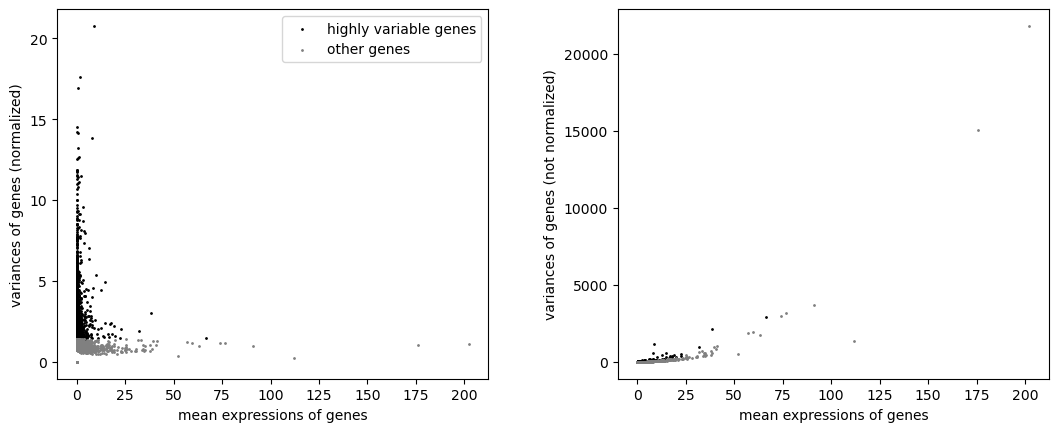

computing PCA
    with n_comps=50
    finished (0:00:00)


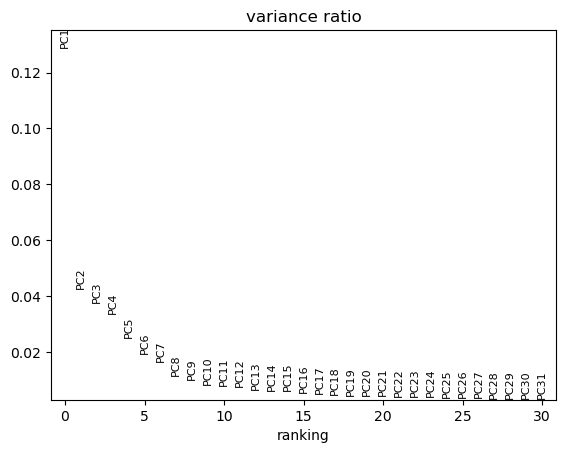

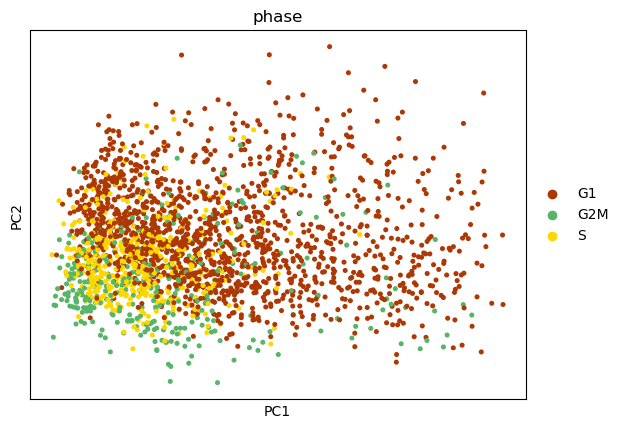

AnnData object with n_obs × n_vars = 2255 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std

In [7]:
tdata.X = tdata.layers['raw_counts'].copy()

sc.pp.highly_variable_genes(
    tdata,
    flavor='seurat_v3',
    n_top_genes=2000,
)

print(f"Number of HVG: {tdata.var['highly_variable'].sum()}")

plt.rcdefaults()
sc.pl.highly_variable_genes(tdata)


tdata.X = tdata.layers['log_norm'].copy()

### PCA with 'filter_pass' genes
sc.pp.pca(
    tdata,
    # mask_var='highly_variable_no_cc',
    # mask_var='filter_pass',
)

sc.pl.pca_variance_ratio(tdata)
sc.pl.pca(
    tdata, 
    color=['phase'],
    ncols=1,
)

tdata

computing neighbors
    using 'X_pca' with n_pcs = 10
    finished (0:00:00)
drawing single-cell graph using layout 'fa'
    finished (0:00:07)
running Leiden clustering
    finished (0:00:00)


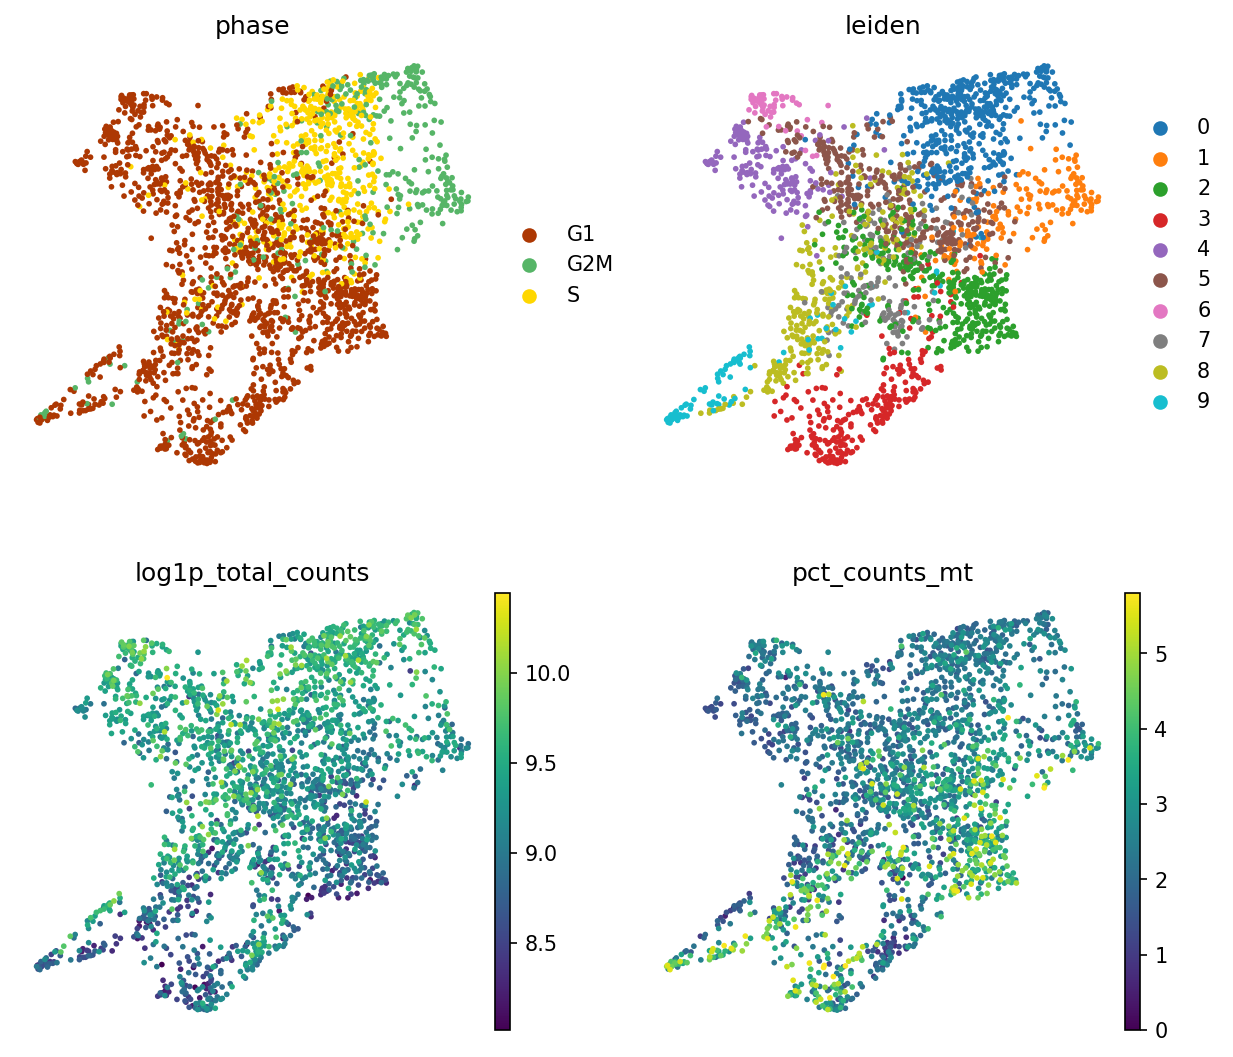

In [14]:
sc.pp.neighbors(
    tdata,
    n_neighbors=10,
    n_pcs=10,
)

# sc.tl.umap(
#     tdata,
#     min_dist=0.2,
#     spread=0.5,
    
# )

sc.tl.draw_graph(
    tdata
)

sc.tl.leiden(
    tdata,
    resolution=0.5,
    flavor='igraph',
)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    tdata,
    color=['phase', 'leiden', 'log1p_total_counts', 'pct_counts_mt'],
    size=30,
    ncols=2,
    frameon=False,
    alpha=1,
)

# sc.pl.umap(
#     tdata,
#     color=['phase', 'leiden', 'log1p_total_counts', 'pct_counts_mt'],
#     size=30,
#     ncols=2,
#     frameon=False,
#     alpha=1,
# )

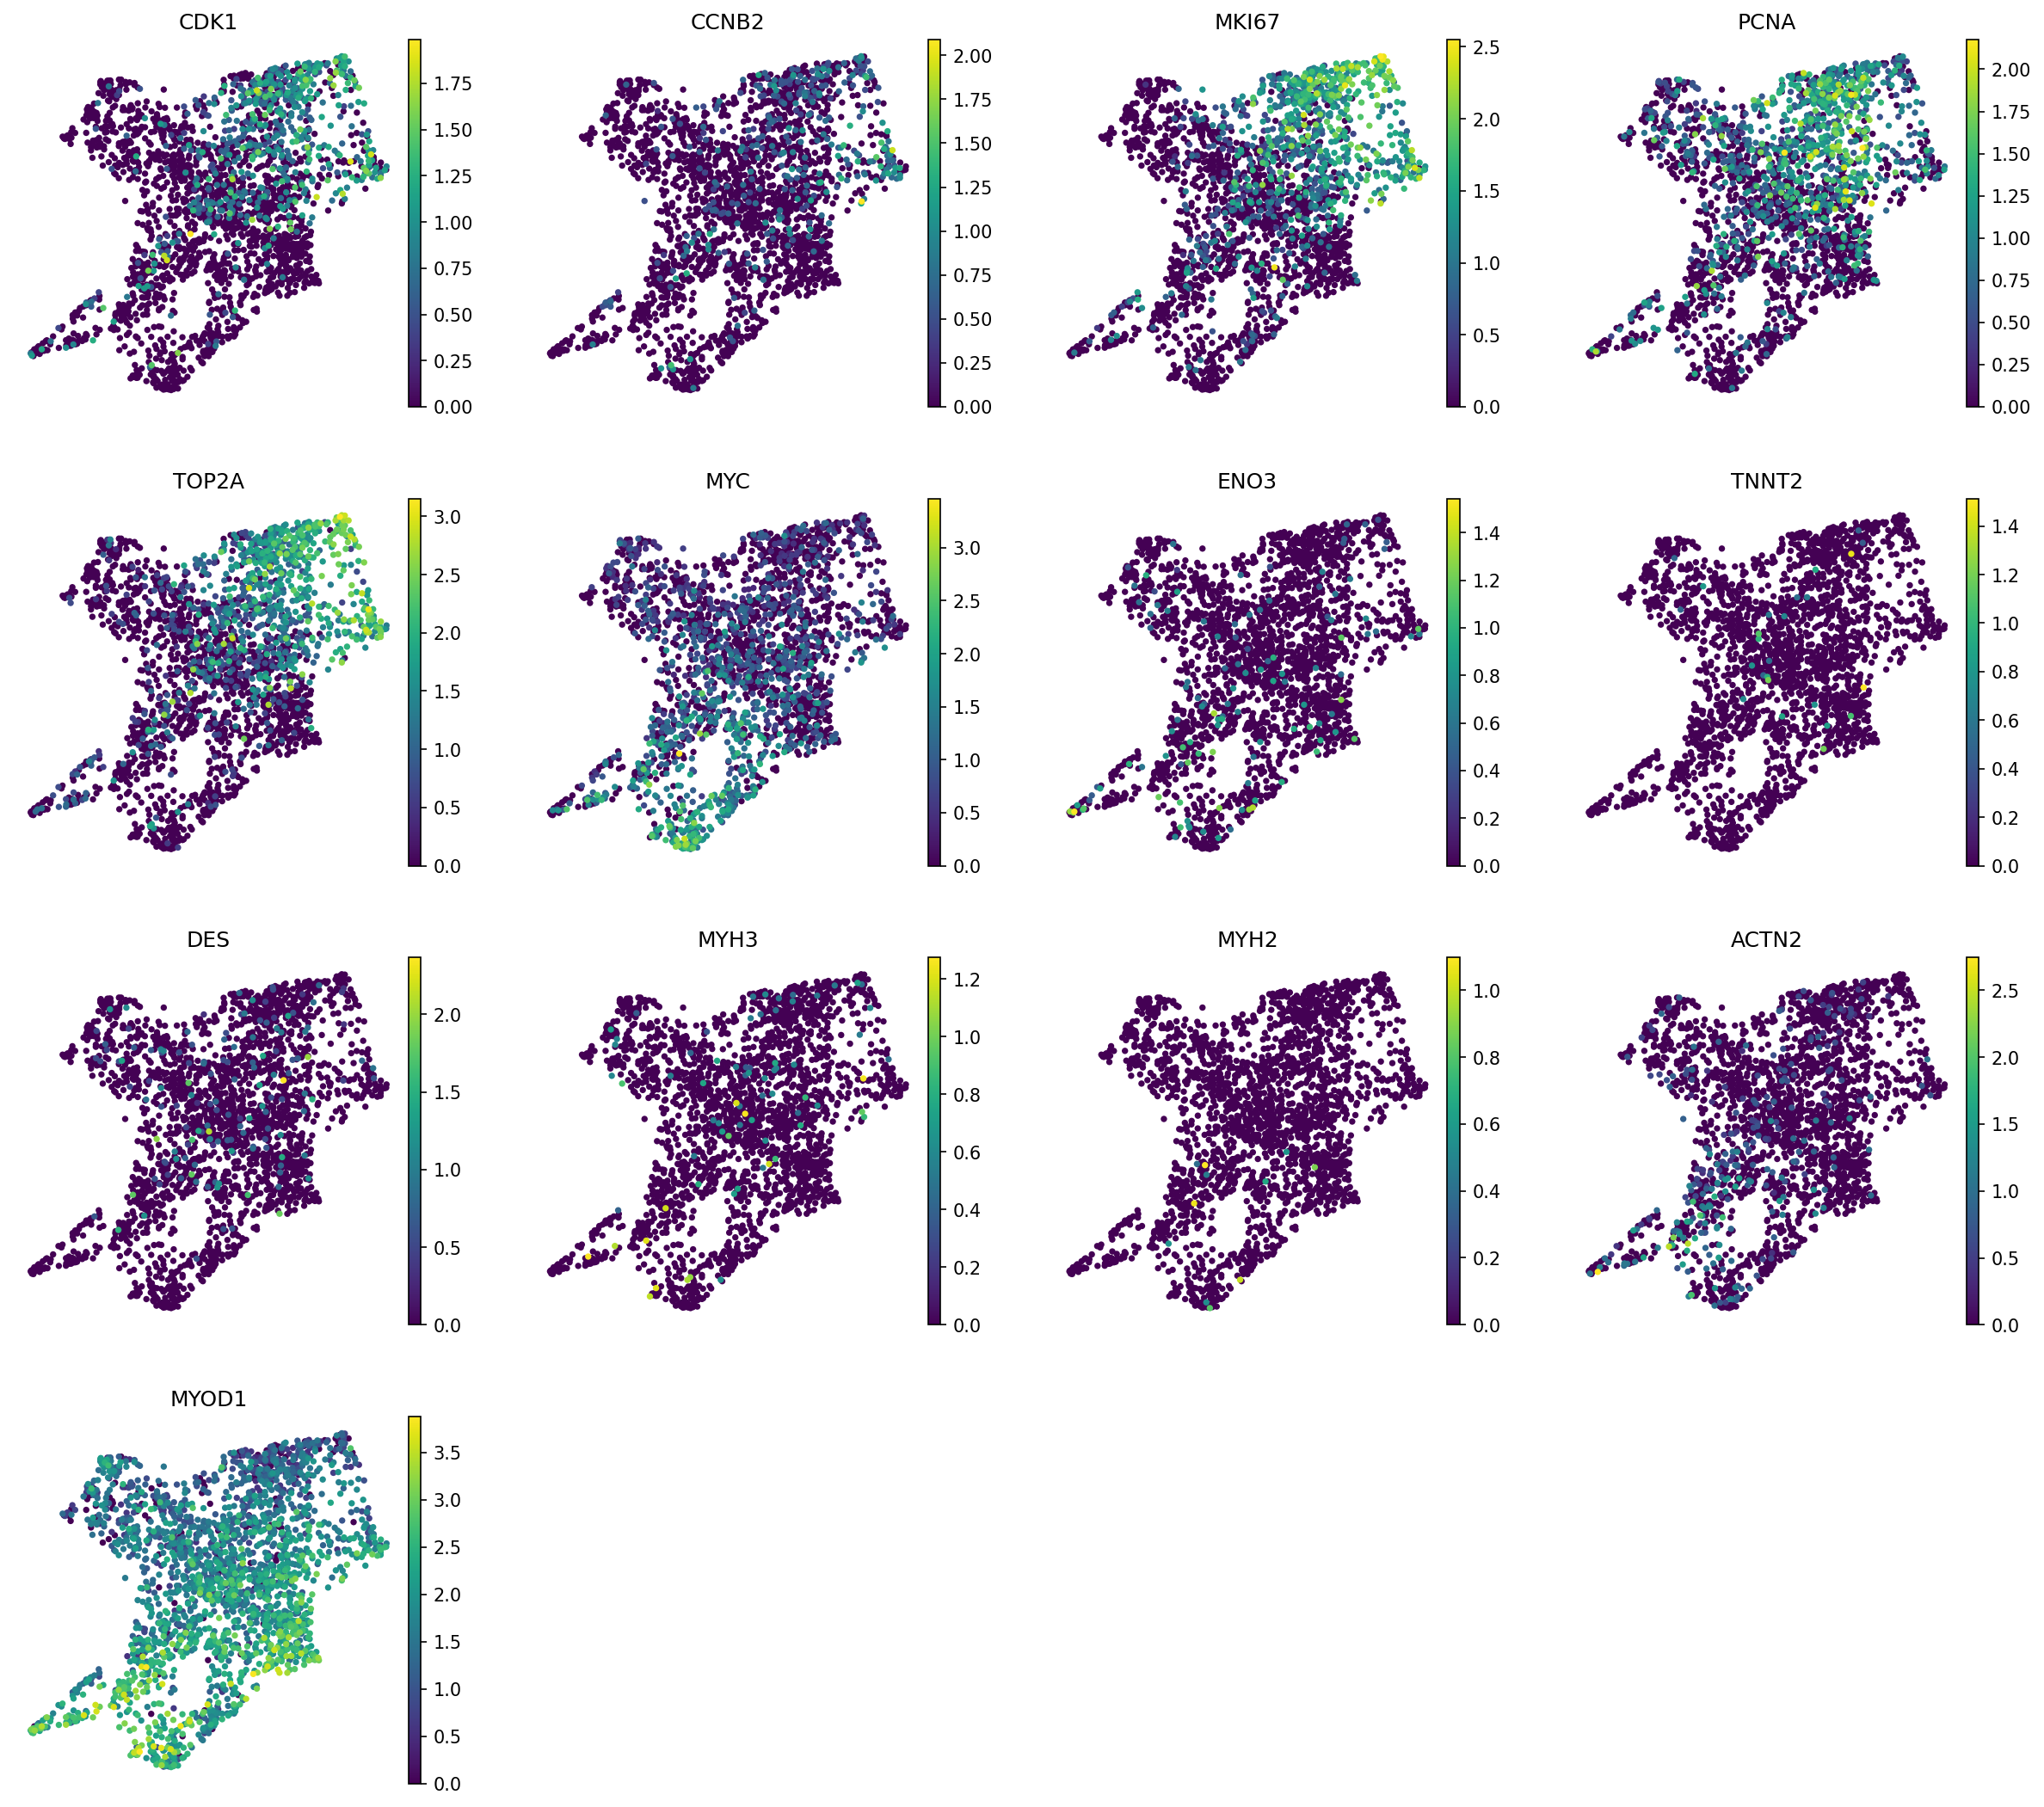

In [17]:
# proliferation markers: CDK1, CCNB2, MKI67, PCNA, TOP2A, PLK1, MYC?
# early myogenic markers: ENO3, TNNT2, DES, MYH3, MYH2 ?

genes_to_plot = [
    'CDK1', 'CCNB2', 'MKI67', 'PCNA', 'TOP2A', 'MYC',
    
    'ENO3', 'TNNT2', 'DES', 'MYH3', 'MYH2', 'ACTN2', 'MYOD1',
]

genes_to_plot = [g for g in genes_to_plot if g in tdata.var_names]

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    tdata,
    color=genes_to_plot,
    size=50,
    ncols=4,
    frameon=False,
    alpha=1,
    layer='log_norm',
)